# 09 — Annotated cell composition by plaque proximity

Load the plaque-proximity AnnData object and plot annotated cell types in **non-overlapping distance ranges from the nearest plaque center**. The ranges are ≤10, 10–15, 15–20, 20–25, 25–30, and 30–50 µm, so every cell appears in at most one bar. Cells with no plaque distance (the mock sample) and cells farther than 50 µm are not included.

In [2]:
from pathlib import Path
import re

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

In [33]:
INPUT_H5AD = Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/08_Plaque_Proximity_Analysis/adata_combined_spatial_with_plaque_edge_15_20_25_30_50um.h5ad")
OUTPUT_DIR = Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/09_Cell_Analysis_From_Plaques")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ANNOTATION_COLUMN = "manual_celltype"
DISTANCE_COLUMN = "distance_to_nearest_plaque_edge_um"
VALID_COLUMN = "plaque_edge_analysis_valid"
INSIDE_PLAQUE_COLUMN = "inside_plaque"

DISTANCES_UM = [10, 15, 20, 25, 30, 50]
INCLUDE_UNKNOWN = True
INCLUDE_CELLS_INSIDE_PLAQUE = True

assert INPUT_H5AD.exists(), f"Input file not found: {INPUT_H5AD}"
print("Input:", INPUT_H5AD)
print("Output:", OUTPUT_DIR)

Input: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/08_Plaque_Proximity_Analysis/adata_combined_spatial_with_plaque_edge_15_20_25_30_50um.h5ad
Output: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/09_Cell_Analysis_From_Plaques


## Load only the metadata needed for this analysis

Backed mode avoids loading the expression matrix into memory. The cell-type palette is recovered from the AnnData object when available.

In [35]:
import re

adata = sc.read_h5ad(INPUT_H5AD)

required_columns = [ANNOTATION_COLUMN, DISTANCE_COLUMN, VALID_COLUMN, INSIDE_PLAQUE_COLUMN]
missing_columns = [column for column in required_columns if column not in adata.obs.columns]
assert not missing_columns, f"Missing columns: {missing_columns}"

cluster_column = "manual_celltype_with_cluster"
optional_columns = ["batch", cluster_column, "nearest_plaque_edge_id"]
columns = required_columns + [column for column in optional_columns if column in adata.obs.columns]
columns = list(dict.fromkeys(columns))

obs = adata.obs[columns].copy()

print(adata)
print("Columns copied:", columns)
print("Valid infected cells:", int(obs[VALID_COLUMN].fillna(False).sum()))
print("Cells inside plaques:", int(obs[INSIDE_PLAQUE_COLUMN].fillna(False).sum()))
print(obs[DISTANCE_COLUMN].describe())

palette = {}
palette_key = "manual_celltype_with_cluster_colors"

if palette_key in adata.uns and cluster_column in adata.obs.columns:
    cluster_labels = adata.obs[cluster_column]

    if not isinstance(cluster_labels.dtype, pd.CategoricalDtype):
        cluster_labels = cluster_labels.astype("category")

    cluster_categories = cluster_labels.cat.categories
    cluster_colors = list(adata.uns[palette_key])

    palette = {
        re.sub(r"^\d+:\s*", "", str(label)): color
        for label, color in zip(cluster_categories, cluster_colors)
    }

print("Palette entries:", len(palette))

print(f"All cells: {len(obs):,}")
print(f"Cells with a plaque-edge distance: {obs[DISTANCE_COLUMN].notna().sum():,}")

if "batch" in obs.columns:
    display(pd.crosstab(
        obs["batch"],
        obs[DISTANCE_COLUMN].notna(),
        rownames=["batch"],
        colnames=["has_plaque_edge_distance"],
        margins=True,
    ))




AnnData object with n_obs × n_vars = 119794 × 480
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'Topic 1', 'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5', 'Topic 6', 'Topic 7', 'Topic 8', 'Topic 9', 'Topic 10', 'Topic 11', 'Topic 12', 'Topic 13', 'Topic 14', 'Topic 15', 'topic', 'batch', '_scvi_batch', '_scvi_labels', 'leiden', 'manual_celltype', 'manual_celltype_with_cluster', 'plaque_edge_analysis_valid', 'nearest_plaque_edge_id', 'distance_to_nearest_plaque_center_um', 'distance_to_nearest_plaque_edge_um', 'inside_plaque', 'within_15um_of_plaque_edge', 'plaque_edge_with

has_plaque_edge_distance,False,True,All
batch,,,
AD_inf,203,55214,55417
AD_mock,64377,0,64377
All,64580,55214,119794


## Assign mutually exclusive plaque-distance ranges

In [37]:
DISTANCE_COLUMN = "distance_to_nearest_plaque_edge_um"
DISTANCE_RANGE_COLUMN = "plaque_edge_distance_range"

bin_edges = [-np.inf, *DISTANCES_UM]
distance_labels = [
    f"≤{DISTANCES_UM[0]} µm",
    *[f"{low}–{high} µm" for low, high in zip(DISTANCES_UM[:-1], DISTANCES_UM[1:])],
]

valid_mask = (
    obs[VALID_COLUMN].fillna(False).to_numpy(bool)
    & obs[DISTANCE_COLUMN].notna().to_numpy()
)

cells = obs.loc[valid_mask].copy()
cells[DISTANCE_RANGE_COLUMN] = pd.cut(
    cells[DISTANCE_COLUMN],
    bins=bin_edges,
    labels=distance_labels,
    include_lowest=True,
    right=True,
)

cells = cells.loc[cells[DISTANCE_RANGE_COLUMN].notna()].copy()
cells[ANNOTATION_COLUMN] = cells[ANNOTATION_COLUMN].astype("string").fillna("Unannotated")

if not INCLUDE_UNKNOWN:
    cells = cells.loc[
        ~cells[ANNOTATION_COLUMN].str.contains("unknown", case=False, na=False)
    ].copy()

print("Cells included:", len(cells))
print("Cells inside plaques:", int(cells[INSIDE_PLAQUE_COLUMN].fillna(False).sum()))

celltype_order = cells[ANNOTATION_COLUMN].value_counts().index.tolist()

counts = (
    pd.crosstab(cells[DISTANCE_RANGE_COLUMN], cells[ANNOTATION_COLUMN], dropna=False)
    .reindex(index=distance_labels, columns=celltype_order, fill_value=0)
)

percent = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).mul(100).fillna(0)

summary = pd.DataFrame({
    "distance_from_plaque_edge": counts.index.astype(str),
    "total_annotated_cells": counts.sum(axis=1).to_numpy(),
    "percent_of_analyzed_cells": 100 * counts.sum(axis=1).to_numpy() / counts.to_numpy().sum(),
})

display(summary)
display(counts)
display(percent.round(2))

distance_labels = [
    "Inside plaque",
    "0–10 µm",
    "10–15 µm",
    "15–20 µm",
    "20–25 µm",
    "25–30 µm",
    "30–50 µm",
]

cells[DISTANCE_RANGE_COLUMN] = pd.Series(pd.NA, index=cells.index, dtype="string")
inside = cells[INSIDE_PLAQUE_COLUMN].fillna(False)
outside_distance = cells[DISTANCE_COLUMN]

cells.loc[inside, DISTANCE_RANGE_COLUMN] = "Inside plaque"
cells.loc[~inside & (outside_distance <= 10), DISTANCE_RANGE_COLUMN] = "0–10 µm"
cells.loc[~inside & (outside_distance > 10) & (outside_distance <= 15), DISTANCE_RANGE_COLUMN] = "10–15 µm"
cells.loc[~inside & (outside_distance > 15) & (outside_distance <= 20), DISTANCE_RANGE_COLUMN] = "15–20 µm"
cells.loc[~inside & (outside_distance > 20) & (outside_distance <= 25), DISTANCE_RANGE_COLUMN] = "20–25 µm"
cells.loc[~inside & (outside_distance > 25) & (outside_distance <= 30), DISTANCE_RANGE_COLUMN] = "25–30 µm"
cells.loc[~inside & (outside_distance > 30) & (outside_distance <= 50), DISTANCE_RANGE_COLUMN] = "30–50 µm"

cells[DISTANCE_RANGE_COLUMN] = pd.Categorical(
    cells[DISTANCE_RANGE_COLUMN],
    categories=distance_labels,
    ordered=True,
)


Cells included: 5230
Cells inside plaques: 176


,distance_from_plaque_edge,total_annotated_cells,percent_of_analyzed_cells
0,≤10 µm,729,13.938815
1,10–15 µm,381,7.284895
2,15–20 µm,410,7.839388
3,20–25 µm,488,9.330784
4,25–30 µm,557,10.650096
5,30–50 µm,2665,50.956023


manual_celltype,Cortical excitatory neurons,Microglia,Oligodendrocytes,Endothelial/Vasculature,Parenchymal astrocytes,Hypothalamic inhibitory neurons,Thalamic excitatory neurons,OPCs,Striatal inhibitory neurons,Dentate gyrus excitatory neurons,Lymphocytes,CA1/CA3 excitatory neurons,Macrophages,unknown (REMOVE),Cholinergic neurons
plaque_edge_distance_range,,,,,,,,,,,,,,,
≤10 µm,44,395,60,88,47,30,21,22,6,0,15,0,1,0,0
10–15 µm,80,119,59,35,35,16,12,15,7,2,1,0,0,0,0
15–20 µm,105,76,57,52,39,32,20,11,12,0,4,2,0,0,0
20–25 µm,122,63,83,62,53,33,17,20,21,5,5,4,0,0,0
25–30 µm,152,50,102,72,68,39,23,17,13,13,4,2,0,1,1
30–50 µm,735,225,418,349,335,230,117,79,84,58,12,20,2,1,0


manual_celltype,Cortical excitatory neurons,Microglia,Oligodendrocytes,Endothelial/Vasculature,Parenchymal astrocytes,Hypothalamic inhibitory neurons,Thalamic excitatory neurons,OPCs,Striatal inhibitory neurons,Dentate gyrus excitatory neurons,Lymphocytes,CA1/CA3 excitatory neurons,Macrophages,unknown (REMOVE),Cholinergic neurons
plaque_edge_distance_range,,,,,,,,,,,,,,,
≤10 µm,6.04,54.18,8.23,12.07,6.45,4.12,2.88,3.02,0.82,0.00,2.06,0.00,0.14,0.00,0.00
10–15 µm,21.00,31.23,15.49,9.19,9.19,4.20,3.15,3.94,1.84,0.52,0.26,0.00,0.00,0.00,0.00
15–20 µm,25.61,18.54,13.90,12.68,9.51,7.80,4.88,2.68,2.93,0.00,0.98,0.49,0.00,0.00,0.00
20–25 µm,25.00,12.91,17.01,12.70,10.86,6.76,3.48,4.10,4.30,1.02,1.02,0.82,0.00,0.00,0.00
25–30 µm,27.29,8.98,18.31,12.93,12.21,7.00,4.13,3.05,2.33,2.33,0.72,0.36,0.00,0.18,0.18
30–50 µm,27.58,8.44,15.68,13.10,12.57,8.63,4.39,2.96,3.15,2.18,0.45,0.75,0.08,0.04,0.00


## Stacked barplots

The upper panel shows cell counts. The lower panel normalizes each distance range to 100%, making shifts in cell-type composition easier to compare when ranges contain different numbers of cells.

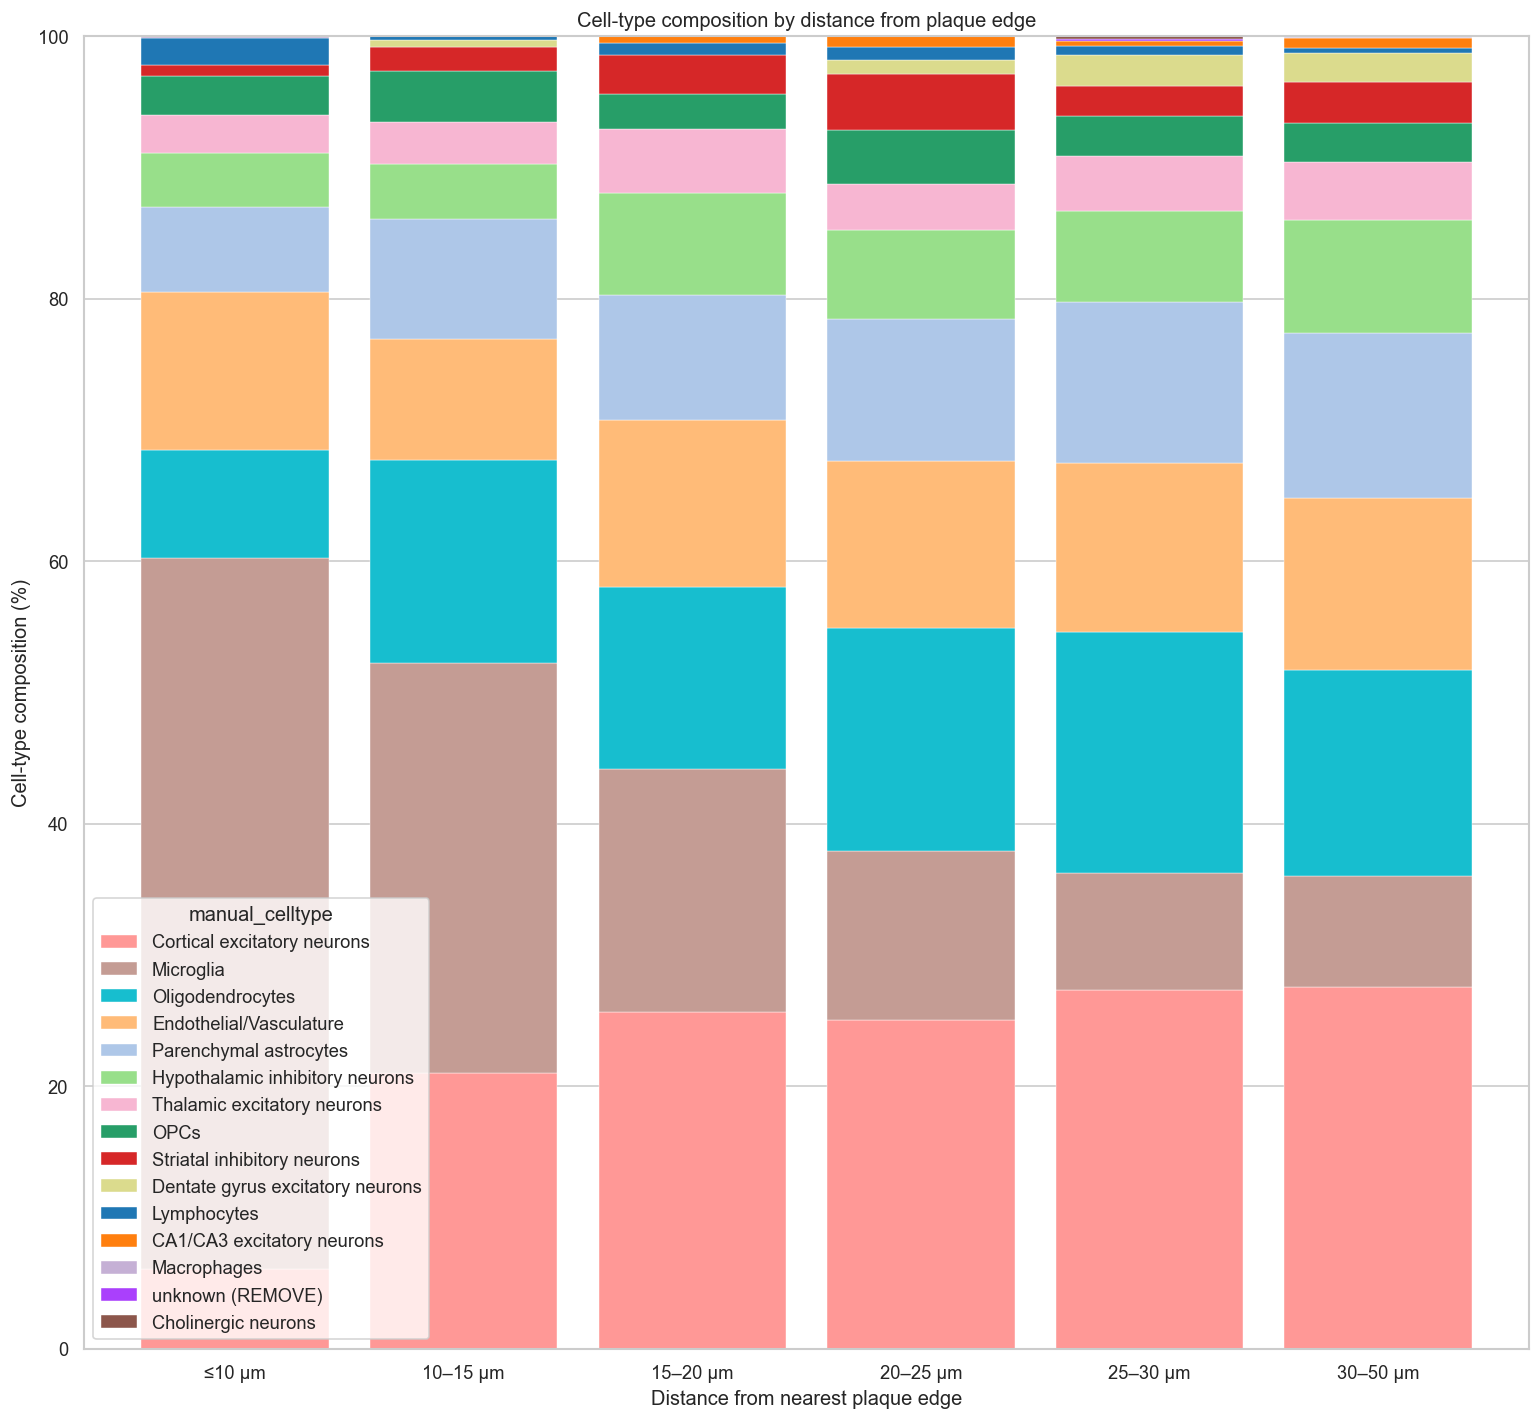

In [39]:
fallback_colors = sns.color_palette("tab20", n_colors=max(1, len(celltype_order))).as_hex()
colors = [palette.get(celltype, fallback_colors[i]) for i, celltype in enumerate(celltype_order)]

fig, ax = plt.subplots(figsize=(13, 12))

percent.plot(
    kind="bar",
    stacked=True,
    color=colors,
    width=0.82,
    ax=ax,
    edgecolor="white",
    linewidth=0.25,
    legend=True,
)

ax.set_title("Cell-type composition by distance from plaque edge")
ax.set_ylabel("Cell-type composition (%)")
ax.set_xlabel("Distance from nearest plaque edge")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)

fig.tight_layout()
plt.show()

## Save figure and source tables

In [40]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
figure_stem = OUTPUT_DIR / "annotated_cells_stacked_barplot_by_plaque_distance"
fig.savefig(figure_stem.with_suffix(".png"), dpi=300, bbox_inches="tight")
counts.to_csv(OUTPUT_DIR / "annotated_cell_counts_by_plaque_distance.csv")
percent.to_csv(OUTPUT_DIR / "annotated_cell_percent_by_plaque_distance.csv")
summary.to_csv(OUTPUT_DIR / "annotated_cell_totals_by_plaque_distance.csv", index=False)

print("Saved:")
for path in sorted(OUTPUT_DIR.glob("annotated_cell*")):
    print(f"  {path}")

Saved:
  /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/09_Cell_Analysis_From_Plaques/annotated_cell_counts_by_plaque_distance.csv
  /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/09_Cell_Analysis_From_Plaques/annotated_cell_percent_by_plaque_distance.csv
  /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/09_Cell_Analysis_From_Plaques/annotated_cell_totals_by_plaque_distance.csv
  /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/2

## Subcluster Lymphocytes and Microglia

In [41]:
GENE_GUIDE_PATH = Path("~/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/Gene List of sub-clustering/BRAIN_CLUSTERING_GUIDE_IRENE_Vs.xlsx").expanduser()
LYMPHOCYTE_RESOLUTION = 0.4
MICROGLIA_RESOLUTION=0.5
RANDOM_STATE=0
N_MARKERS_PER_CLUSTER=25

gene_guide = pd.read_excel(GENE_GUIDE_PATH, sheet_name="Long_format_all_genes")
gene_guide


,Gene,Type
0,Cd19,Bcells
1,Cd79a,Bcells
2,Cd79b,Bcells
3,Ms4a1,Bcells
4,Cd22,Bcells
...,...,...
192,Cd80,Dendritic Cells
193,Itgam,Dendritic Cells
194,Ccr7,Dendritic Cells
195,Cd290a,Dendritic Cells


In [42]:
gene_guide["Type"].value_counts()
gene_guide_mapping = {
    "T-cells": ["Tcells"],
    "B-cells": ["Bcells"],
    "DAM": ["DAM_stage1", "DAM_stage2", "DAM_microglia"],
    "HOM": ["Hom_microglia"]
}
# Clean the Excel Type column
gene_guide["Type"] = gene_guide["Type"].astype(str).str.strip()
available_types = set(gene_guide["Type"].dropna())

# Check every requested Excel type
mapping_check = pd.DataFrame([
    {
        "new_annotation": label,
        "excel_type": excel_type,
        "found_in_excel": excel_type in available_types,
    }
    for label, excel_types in gene_guide_mapping.items()
    for excel_type in excel_types
])

display(mapping_check)

missing_types = mapping_check.loc[
    ~mapping_check["found_in_excel"], "excel_type"
].tolist()

if missing_types:
    raise ValueError(f"Marker types not found in Excel: {missing_types}")

# Use isin(), because excel_types is a list
requested_marker_sets = {
    label: (gene_guide.loc[gene_guide["Type"].isin(excel_types), "Gene"].dropna().drop_duplicates().tolist())
    for label, excel_types in gene_guide_mapping.items()
}

for label, genes in requested_marker_sets.items():
    print(f"{label} ({len(genes)} genes): {', '.join(genes)}")

,new_annotation,excel_type,found_in_excel
0,T-cells,Tcells,True
1,B-cells,Bcells,True
2,DAM,DAM_stage1,True
3,DAM,DAM_stage2,True
4,DAM,DAM_microglia,True
5,HOM,Hom_microglia,True


T-cells (7 genes): Cd3d, Cd3e, Cd3g, Cd2, Cd4, Cd8a, Foxp3
B-cells (9 genes): Cd19, Cd79a, Cd79b, Ms4a1, Cd22, Ebf1, Ighd, Ighm, Fcmr
DAM (40 genes): Trem2, Apoe, Tyrobp, Cst7, Ctsl, Lpl, Axl, Clec7a, Itgax, Lgals3, Csf1, Gpnmb, B2m, Cd9, Fabp5, Ch25h, Spp1, Timp2, Ctsb, Ctsd, Fth1, Lyz2, Serpina3n, Ifitm3, Tubb5, Actb, Tmsb10, Vim, Ifi27l2a, Ifitm2, Tnfaip2, Itgax (CD11c), Cd63, Csf1r, Hexb, Lgals1, Cd68, Ccl6, Fcer1g, Fcgr2b
HOM (5 genes): Tmem119, Cx3cr1, P2ry12, Sall1, Siglech


### Subclustering functions

In [43]:
import scanpy as sc
def mean_expression(adata_subset, genes):
    values = adata_subset[:, genes].X
    return np.asarray(values).mean(axis=1)

def subcluster_population(adata, original_celltype, prefix, resolution):
    mask = adata.obs["manual_celltype"].astype(str).eq(original_celltype)
    subset = adata[mask].to_memory() if adata.isbacked else adata[mask].copy()

    if subset.n_obs < 20:
        raise ValueError(f"Only {subset.n_obs} cells were found for {original_celltype!r}")

    subset.X = subset.layers["counts"].copy()
    subset.uns.pop("log1p", None)
    sc.pp.normalize_total(subset, target_sum=1e4)
    sc.pp.log1p(subset)
    subset.raw = subset.copy()

    n_comps = min(30, subset.n_obs - 1, subset.n_vars - 1)
    sc.pp.pca(subset, n_comps=n_comps, svd_solver="arpack", random_state=RANDOM_STATE)
    sc.pp.neighbors(subset, n_neighbors=min(15, subset.n_obs - 1), n_pcs=n_comps, random_state=RANDOM_STATE)
    sc.tl.umap(subset, random_state=RANDOM_STATE)

    leiden_key = f"{prefix}_leiden"
    sc.tl.leiden(
        subset,
        resolution=resolution,
        key_added=leiden_key,
        random_state=RANDOM_STATE,
        flavor="leidenalg",
    )

    print(f"{original_celltype}: {subset.n_obs:,} cells")
    display(subset.obs[leiden_key].value_counts().sort_index().to_frame("cells"))

    return subset, leiden_key

def find_cluster_markers(subset, leiden_key, prefix):
    output_dir = Path(OUTPUT_DIR).expanduser()
    output_dir.mkdir(parents=True, exist_ok=True)

    if subset.obs[leiden_key].nunique() < 2:
        raise ValueError(f"{prefix} generated fewer than two Leiden clusters")

    rank_key = f"rank_genes_{prefix}_leiden"
    sc.tl.rank_genes_groups(
        subset, groupby=leiden_key, method="wilcoxon",
        use_raw=True, pts=True, key_added=rank_key
    )

    markers = sc.get.rank_genes_groups_df(subset, group=None, key=rank_key)
    top_markers = markers.groupby("group", observed=True).head(N_MARKERS_PER_CLUSTER)

    markers.to_csv(output_dir / f"{prefix}_leiden_all_markers.csv", index=False)
    top_markers.to_csv(
        output_dir / f"{prefix}_leiden_top_{N_MARKERS_PER_CLUSTER}_markers.csv",
        index=False,
    )

    display(top_markers.groupby("group", observed=True).head(10))
    return markers

def assign_clusters(subset, leiden_key, label_to_genes, annotation_key):
    score_to_label = {}

    for label, genes in label_to_genes.items():
        genes = [str(g) for g in genes if str(g) in subset.var_names]
        if not genes:
            raise ValueError(f"No marker genes found in the data for {label}")

        score_col = "score_" + re.sub(r"[^A-Za-z0-9]+", "_", label).strip("_").lower()
        X = subset[:, genes].X
        subset.obs[score_col] = np.asarray(X.mean(axis=1)).ravel()
        score_to_label[score_col] = label

        print(f"{label}: using {len(genes)} genes — {', '.join(genes)}")

    score_cols = list(score_to_label)
    scores = subset.obs.groupby(leiden_key, observed=True)[score_cols].mean()
    scores[annotation_key] = scores[score_cols].idxmax(axis=1).map(score_to_label)
    scores.insert(0, "n_cells", subset.obs[leiden_key].value_counts().reindex(scores.index))
    subset.obs[annotation_key] = subset.obs[leiden_key].map(scores[annotation_key]).astype("category")
    return scores


#### Lymphocyte subclustering

Lymphocytes: 429 cells


,cells
lymphocyte_leiden,
0,236
1,98
2,60
3,19
4,16


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,Ccl5,14.599808,8.053281,2.816372e-48,1.351859e-45,0.894068,0.108808
1,0,Cxcr6,12.574058,6.550567,2.932778e-36,7.038667e-34,0.771186,0.088083
2,0,Cxcr3,12.455862,6.504803,1.299392e-35,2.079028e-33,0.750000,0.082902
3,0,Cd8a,12.334928,6.754311,5.874148e-35,7.048978e-33,0.754237,0.088083
4,0,Trbc1,12.274265,5.563208,1.245175e-34,1.195368e-32,0.894068,0.248705
5,0,Cd3e,11.987780,5.338378,4.117971e-33,3.294377e-31,0.826271,0.196891
6,0,B2m,11.463730,3.405195,2.006823e-30,1.376107e-28,0.987288,0.673575
7,0,Cd8b1,11.134584,5.961599,8.514115e-29,5.108469e-27,0.699153,0.098446
8,0,Itgb2,10.727164,4.358013,7.588928e-27,4.047428e-25,0.851695,0.295337
9,0,Cd226,10.086486,5.179901,6.339890e-24,3.043147e-22,0.648305,0.098446


T-cells: using 5 genes — Cd3e, Cd2, Cd4, Cd8a, Foxp3
B-cells: using 4 genes — Cd19, Ms4a1, Ighd, Ighm


,n_cells,score_t_cells,score_b_cells,lymphocyte_subtype
lymphocyte_leiden,,,,
0,236,2.371992,0.298252,T-cells
1,98,0.173418,0.548064,B-cells
2,60,0.514194,4.394952,B-cells
3,19,2.588870,0.884552,T-cells
4,16,2.400158,0.810485,T-cells


lymphocyte_subtype
T-cells    271
B-cells    158
Name: count, dtype: int64


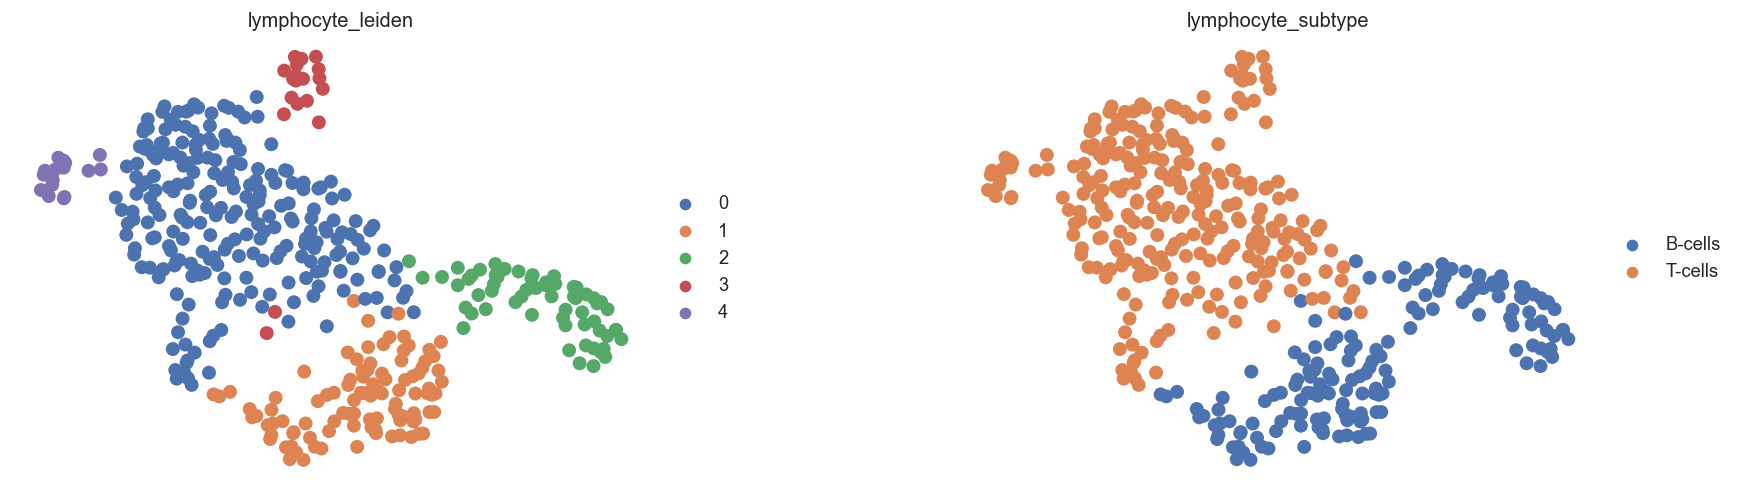

In [44]:
lymphocytes, lymph_leiden = subcluster_population(adata, original_celltype="Lymphocytes", prefix="lymphocyte", resolution=LYMPHOCYTE_RESOLUTION)
lymphocyte_markers = find_cluster_markers(lymphocytes, lymph_leiden, "lymphocyte")
lymphocyte_scores = assign_clusters(
    lymphocytes, lymph_leiden,
    {"T-cells": requested_marker_sets["T-cells"], "B-cells": requested_marker_sets["B-cells"]},
    annotation_key="lymphocyte_subtype",
)

display(lymphocyte_scores)
print(lymphocytes.obs["lymphocyte_subtype"].value_counts())

sc.pl.umap(lymphocytes, color=[lymph_leiden, "lymphocyte_subtype"], wspace=0.35, frameon=False, show=False)
# plt.savefig(OUTPUT_DIR / "lymphocyte_umap_leiden_and_subtype.png", dpi=300, bbox_inches="tight")
plt.show()

#### 1. Prepare guide genes available in the dataset

In [45]:
lymphocyte_guide_genes = {
    "T-cell genes": [g for g in requested_marker_sets["T-cells"] if g in lymphocytes.var_names],
    "B-cell genes": [g for g in requested_marker_sets["B-cells"] if g in lymphocytes.var_names],
    "DAM genes": [g for g in requested_marker_sets["DAM"] if g in lymphocytes.var_names],
    "HOM genes": [g for g in requested_marker_sets["HOM"] if g in lymphocytes.var_names]
}

for group, genes in lymphocyte_guide_genes.items():
    print(f"{group}: {', '.join(genes)}")

T-cell genes: Cd3e, Cd2, Cd4, Cd8a, Foxp3
B-cell genes: Cd19, Ms4a1, Ighd, Ighm
DAM genes: Trem2, Apoe, Axl, Itgax, B2m, Cd9, Fabp5, Spp1, Actb, Vim, Csf1r, Fcgr2b
HOM genes: Tmem119, Cx3cr1, P2ry12


#### 2. Heatmap of top upregulated genes per Leiden cluster

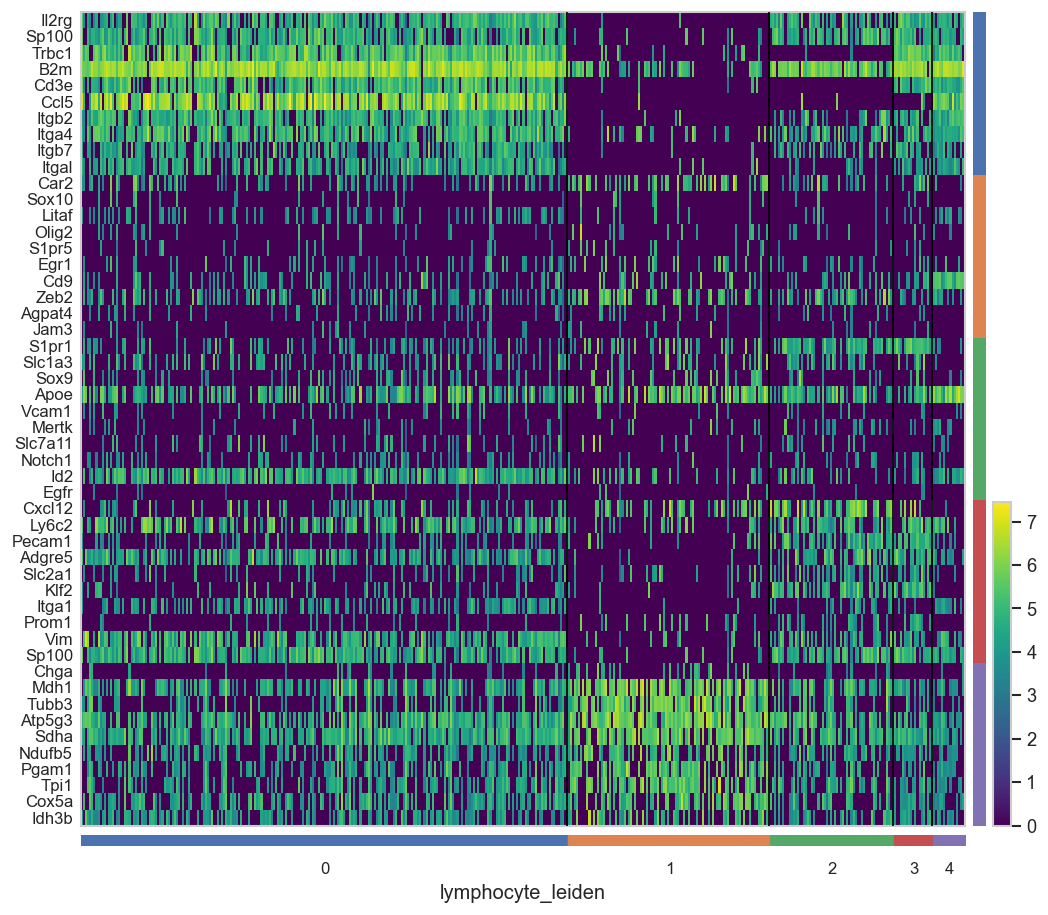

In [46]:
cluster_order = ["0", "1", "2", "3", "4", "5"]
observed = set(lymphocytes.obs[lymph_leiden].astype(str))
cluster_order = [cluster for cluster in cluster_order if cluster in observed]

lymphocytes.obs[lymph_leiden] = pd.Categorical(lymphocytes.obs[lymph_leiden].astype(str), categories=cluster_order, ordered=True)

sc.pl.rank_genes_groups_heatmap(
    lymphocytes,
    groupby=lymph_leiden,
    # key=lymphocyte_markers,
    groups=cluster_order,
    n_genes=10,
    use_raw=True,
    swap_axes=True,
    dendrogram=False,
    show_gene_labels=True,
    cmap="viridis",
    show=False,
)

plt.savefig(
    Path(OUTPUT_DIR) / "lymphocyte_top10_genes_heatmap_ordered.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

#### 3. Dotplot of T-cell and B-cell guide genes

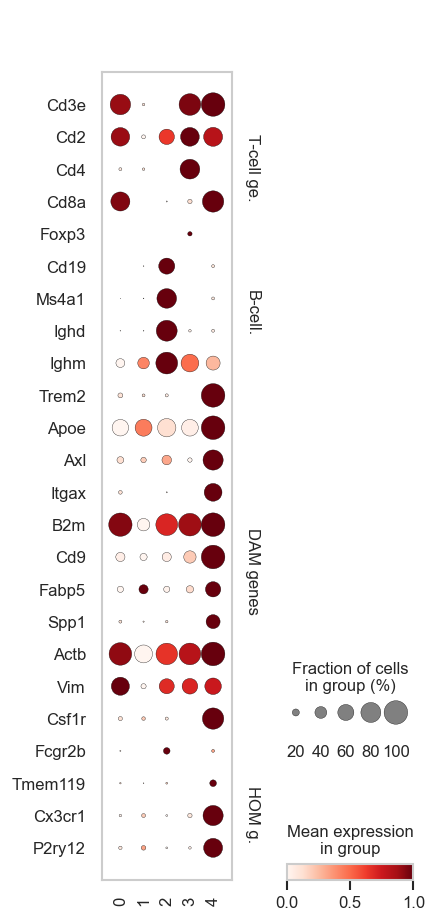

In [47]:
sc.pl.dotplot(lymphocytes, var_names=lymphocyte_guide_genes, groupby=lymph_leiden, use_raw=True, standard_scale="var", dendrogram=False, color_map="Reds", show=False, swap_axes=True)
# plt.savefig(OUTPUT_DIR / "lymphocyte_guide_genes_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

#### 4. Violin plots of guide genes by Leiden cluster

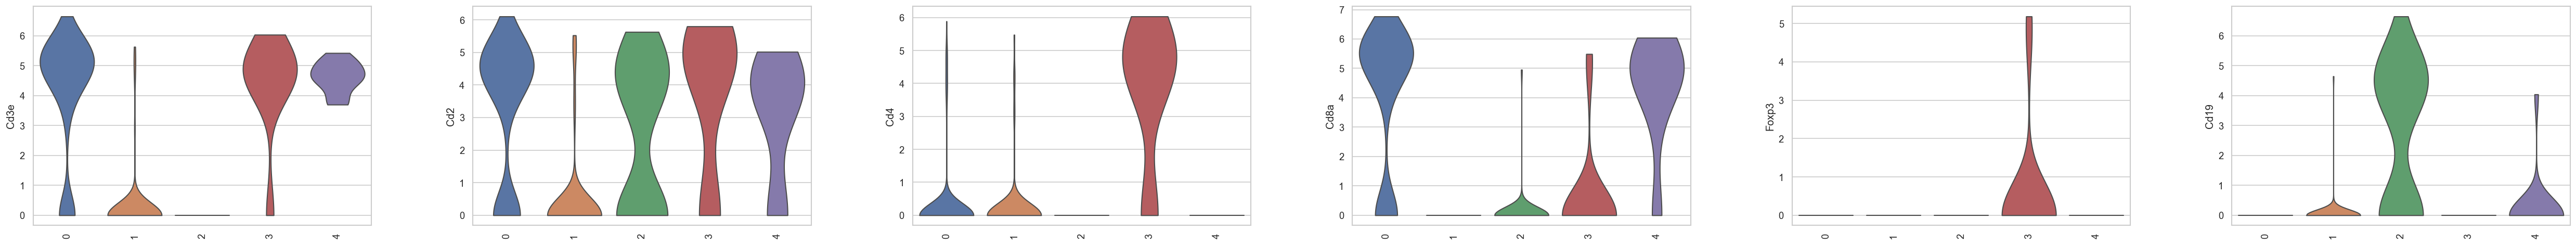

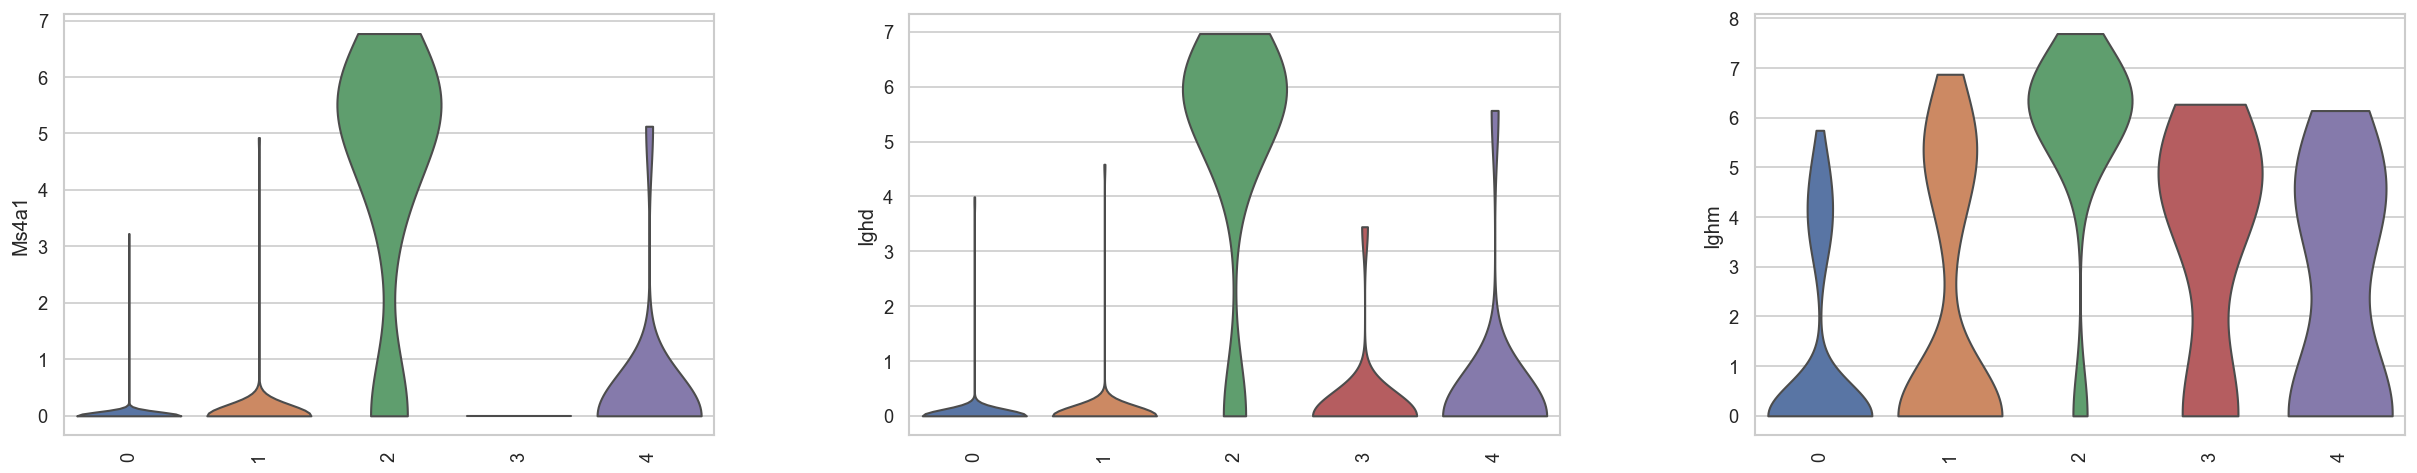

In [48]:
all_lymphocyte_guide_genes = list(dict.fromkeys(lymphocyte_guide_genes["T-cell genes"] + lymphocyte_guide_genes["B-cell genes"]))

for start in range(0, len(all_lymphocyte_guide_genes), 6):
    genes, page = all_lymphocyte_guide_genes[start:start + 6], start // 6 + 1
    sc.pl.violin(lymphocytes, keys=genes, groupby=lymph_leiden, use_raw=True, multi_panel=True, rotation=90, stripplot=False, show=False)
    # plt.savefig(OUTPUT_DIR / f"lymphocyte_guide_genes_violin_page_{page}.png", dpi=300, bbox_inches="tight")
    plt.show()

#### 4. Feature plots of guide genes on the subclusters UMAP

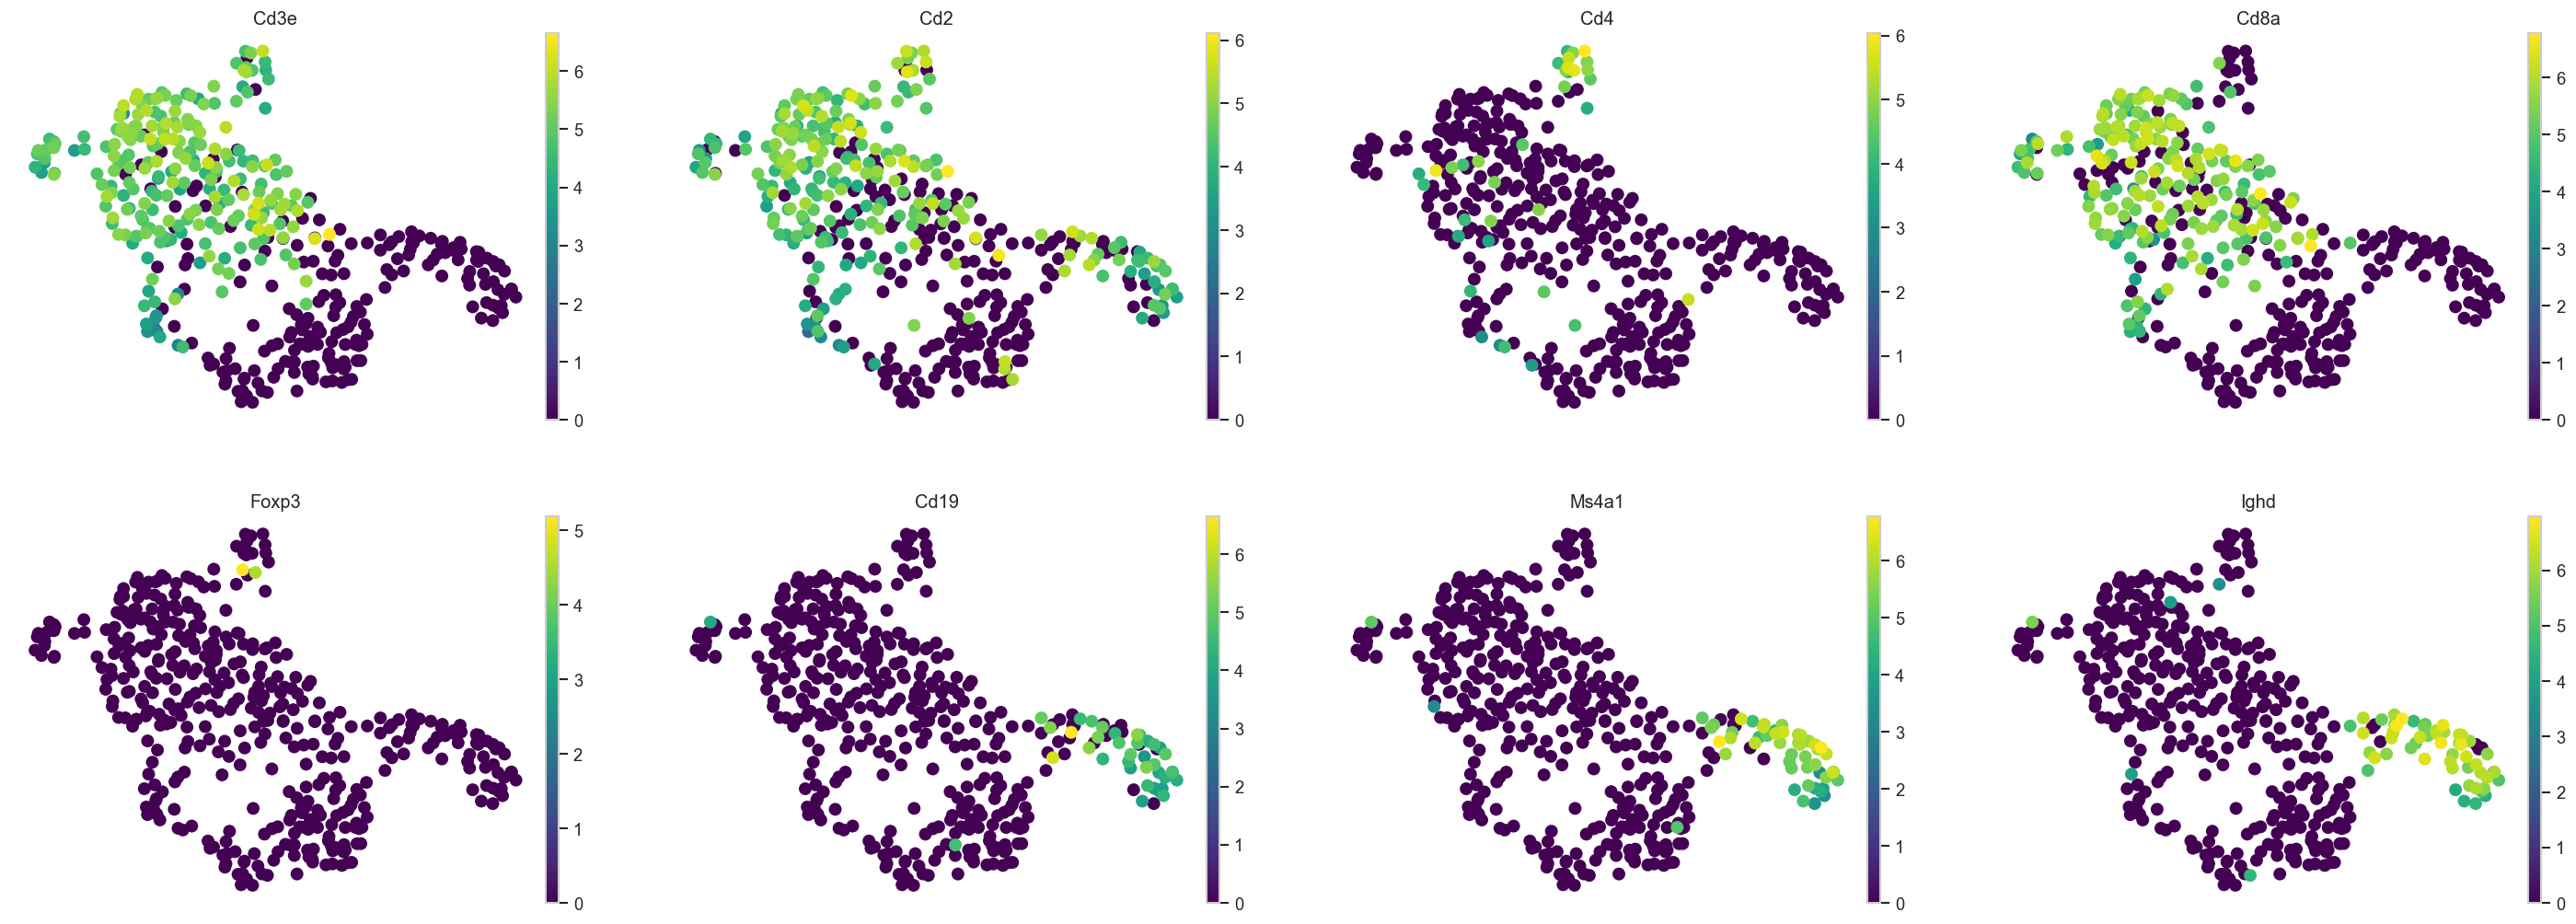

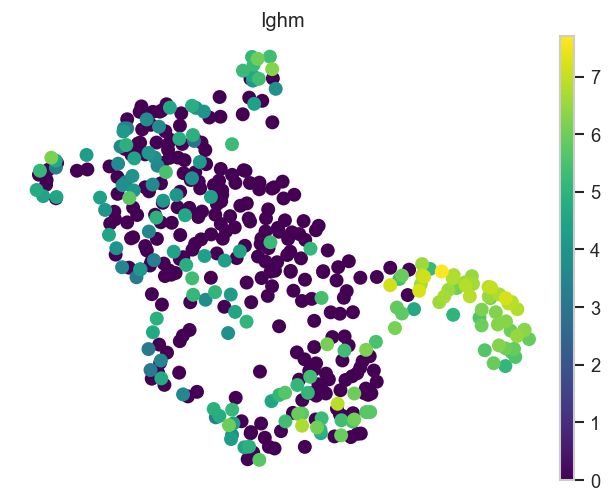

In [49]:
for start in range(0, len(all_lymphocyte_guide_genes), 8):
    genes, page = all_lymphocyte_guide_genes[start:start + 8], start // 8 + 1
    sc.pl.umap(
        lymphocytes, color=genes, use_raw=True, ncols=4,
        cmap="viridis", frameon=False, show=False,
    )
    # plt.savefig(OUTPUT_DIR / f"lymphocyte_guide_genes_featureplots_page_{page}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [50]:
lymphocyte_cluster_mapping = {
    "0": "CD8",
    "1": "Bcells",
    "2": "Bcells",
    "3": "CD4",
    "4": "CD8"
}

# Assign subtype; unspecified clusters remain Lymphocytes
cluster_ids = lymphocytes.obs[lymph_leiden].astype(str)
lymphocytes.obs["lymphocyte_subtype"] = cluster_ids.map(lymphocyte_cluster_mapping).fillna("Lymphocytes").astype("category")

display(pd.crosstab(cluster_ids, lymphocytes.obs["lymphocyte_subtype"]))
print("Unassigned clusters:", sorted(set(cluster_ids) - set(lymphocyte_cluster_mapping)))

lymphocyte_subtype,Bcells,CD4,CD8
lymphocyte_leiden,,,
0,0,0,236
1,98,0,0
2,60,0,0
3,0,19,0
4,0,0,16


Unassigned clusters: []


In [51]:
# Preserve the original annotations
if "manual_celltype_original" not in adata.obs:
    adata.obs["manual_celltype_original"] = adata.obs["manual_celltype"].astype(str)

updated_celltypes = adata.obs["manual_celltype"].astype(str).copy()
updated_celltypes.loc[lymphocytes.obs_names] = lymphocytes.obs["lymphocyte_subtype"].astype(str).to_numpy()
adata.obs["manual_celltype"] = updated_celltypes.astype("category")

# Also retain the lymphocyte Leiden cluster
adata.obs["lymphocyte_leiden"] = pd.Series(pd.NA, index=adata.obs_names, dtype="string")
adata.obs.loc[lymphocytes.obs_names, "lymphocyte_leiden"] = cluster_ids.to_numpy()

display(pd.crosstab(
    adata.obs.loc[lymphocytes.obs_names, "lymphocyte_leiden"],
    adata.obs.loc[lymphocytes.obs_names, "manual_celltype"],
))

manual_celltype,Bcells,CD4,CD8
lymphocyte_leiden,,,
0,0,0,236
1,98,0,0
2,60,0,0
3,0,19,0
4,0,0,16


In [52]:
print(adata.obs["manual_celltype"].value_counts().reindex(["CD4", "CD8", "Bcells", "Lymphocytes"], fill_value=0))

manual_celltype
CD4             19
CD8            252
Bcells         158
Lymphocytes      0
Name: count, dtype: int64


In [53]:
adata.obs["manual_celltype"].value_counts()

manual_celltype
Oligodendrocytes                    26364
Parenchymal astrocytes              16318
Endothelial/Vasculature             14187
Hypothalamic inhibitory neurons     13393
Cortical excitatory neurons         13269
Microglia                            8738
Thalamic excitatory neurons          7428
Dentate gyrus excitatory neurons     4551
CA1/CA3 excitatory neurons           4004
OPCs                                 3294
Striatal inhibitory neurons          2573
unknown (REMOVE)                     1967
Cholinergic neurons                  1401
Periventricular astrocytes           1085
Choroid plexus epithelium             665
CD8                                   252
Bcells                                158
Macrophages                           128
CD4                                    19
Name: count, dtype: int64

#### Subcluster Microglia

Microglia: 8,738 cells


,cells
microglia_leiden,
0,3285
1,1964
2,1851
3,1638


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,Gfap,53.203751,3.680272,0.000000e+00,0.000000e+00,0.882801,0.731524
1,0,Gpm6b,47.218075,1.710411,0.000000e+00,0.000000e+00,0.857230,0.873648
2,0,Gpx4,21.096743,-0.032020,8.520824e-99,5.381573e-98,0.655403,0.823767
3,0,S100b,7.328544,1.015496,2.326673e-13,5.992135e-13,0.299239,0.282413
4,0,Cacnb3,4.481719,0.724264,7.404428e-06,1.653082e-05,0.265449,0.272694
5,0,Hist1h2bc,3.330870,0.082624,8.657513e-04,1.724318e-03,0.371385,0.493306
6,0,Scd1,2.411022,0.458255,1.590788e-02,2.903340e-02,0.268493,0.314689
7,0,Aldh1a1,2.036805,0.735848,4.166962e-02,7.168968e-02,0.154947,0.150009
8,0,Fads1,1.927319,0.093939,5.393992e-02,9.148820e-02,0.340030,0.458830
9,0,Sox9,1.586648,0.466495,1.125925e-01,1.807505e-01,0.218874,0.246103


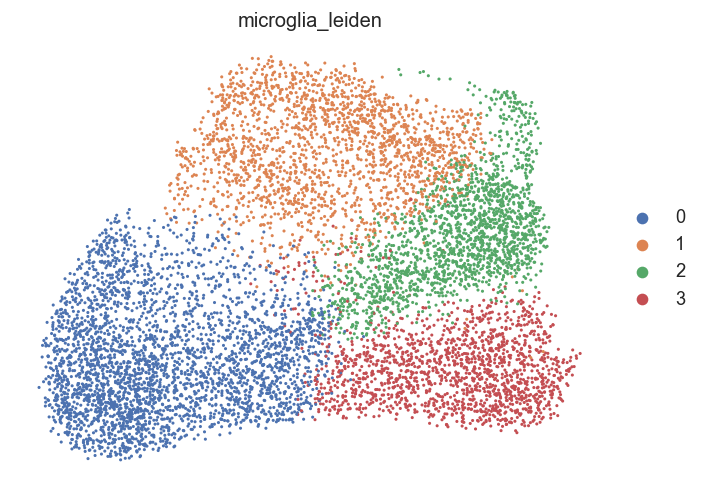

In [89]:
microglia, mic_leiden = subcluster_population(adata, original_celltype="Microglia", prefix="microglia", resolution=0.35)
microglia_markers = find_cluster_markers(microglia, mic_leiden, "microglia")

sc.pl.umap(microglia, color="microglia_leiden", wspace=0.35, frameon=False, show=False)
# plt.savefig(OUTPUT_DIR / "microglia_umap_leiden_and_subtype.png", dpi=300, bbox_inches="tight")
plt.show()

#### Heatmap of top upregulated genes per Leiden cluster

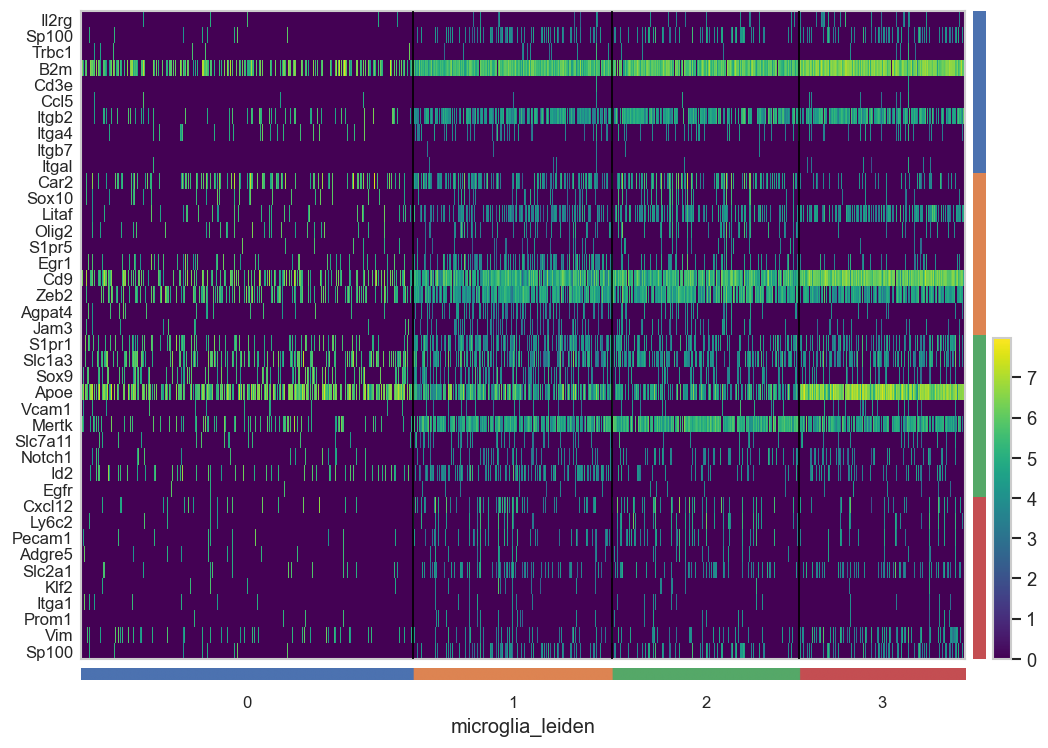

In [97]:
microglia_rank_key = "rank_genes_microglia_leiden"
cluster_order = ["0", "1", "2", "3"]
# sc.tl.rank_genes_groups(microglia, groupby="microglia_leiden", method="wilcoxon", use_raw=True, pts=True, key_added=microglia_rank_key)


observed = set(microglia.obs["microglia_leiden"].astype(str))
microglia.obs["microglia_leiden"] = pd.Categorical(microglia.obs["microglia_leiden"].astype(str), categories=cluster_order, ordered=True)

sc.pl.rank_genes_groups_heatmap(microglia, groupby="microglia_leiden", groups=cluster_order, n_genes=10, use_raw=True, swap_axes=True, dendrogram=False, show_gene_labels=True, cmap="viridis", show=False)
# plt.savefig(OUTPUT_DIR / "microglia_top10_genes_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

#### Dotplot of Microglia subclusters

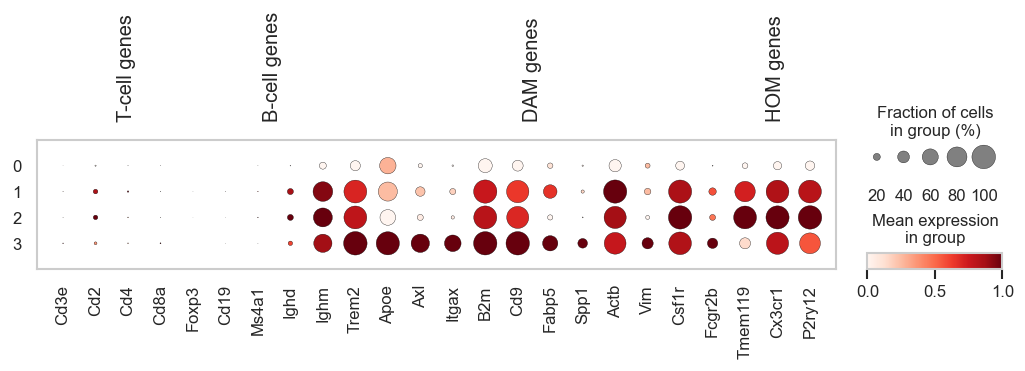

In [98]:
sc.pl.dotplot(microglia, var_names=lymphocyte_guide_genes, groupby="microglia_leiden", use_raw=True, standard_scale="var", dendrogram=False, color_map="Reds", show=False)
# plt.savefig(OUTPUT_DIR / "microglia_guide_genes_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

#### Violin plots for guide genes by Leiden cluster

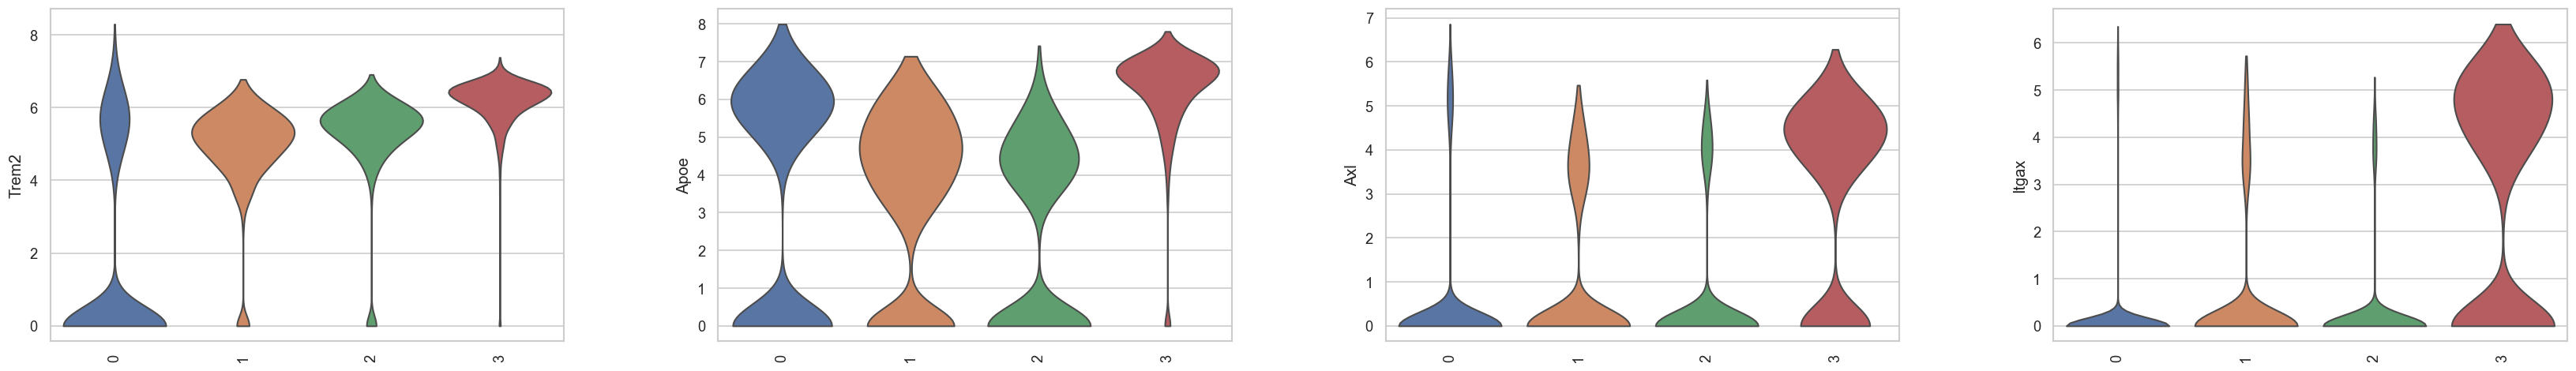

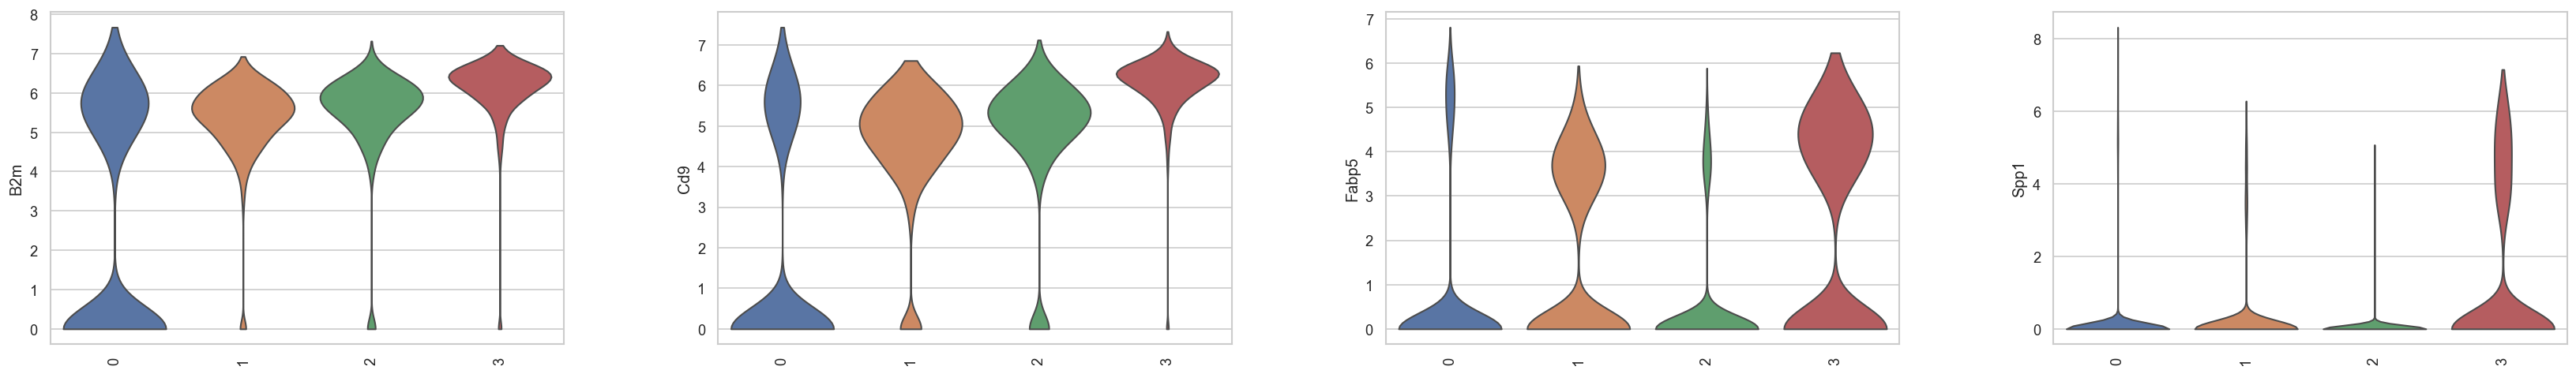

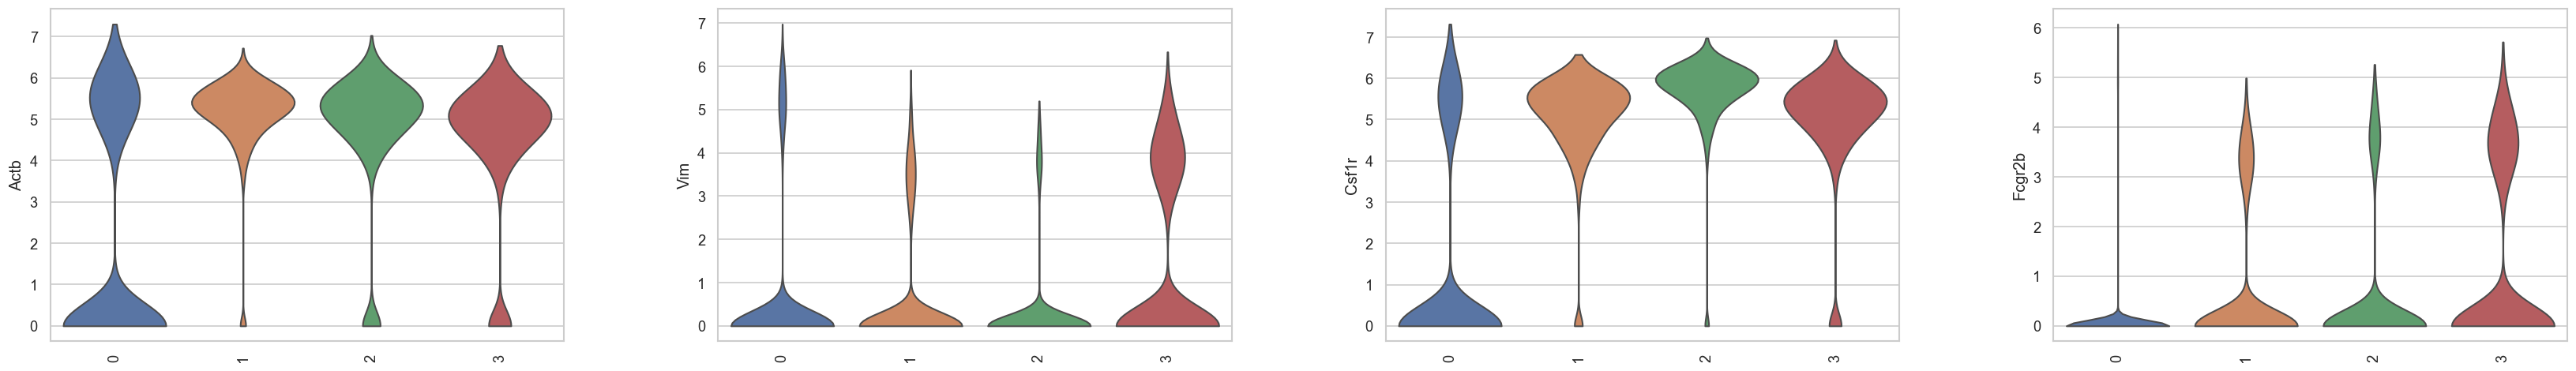

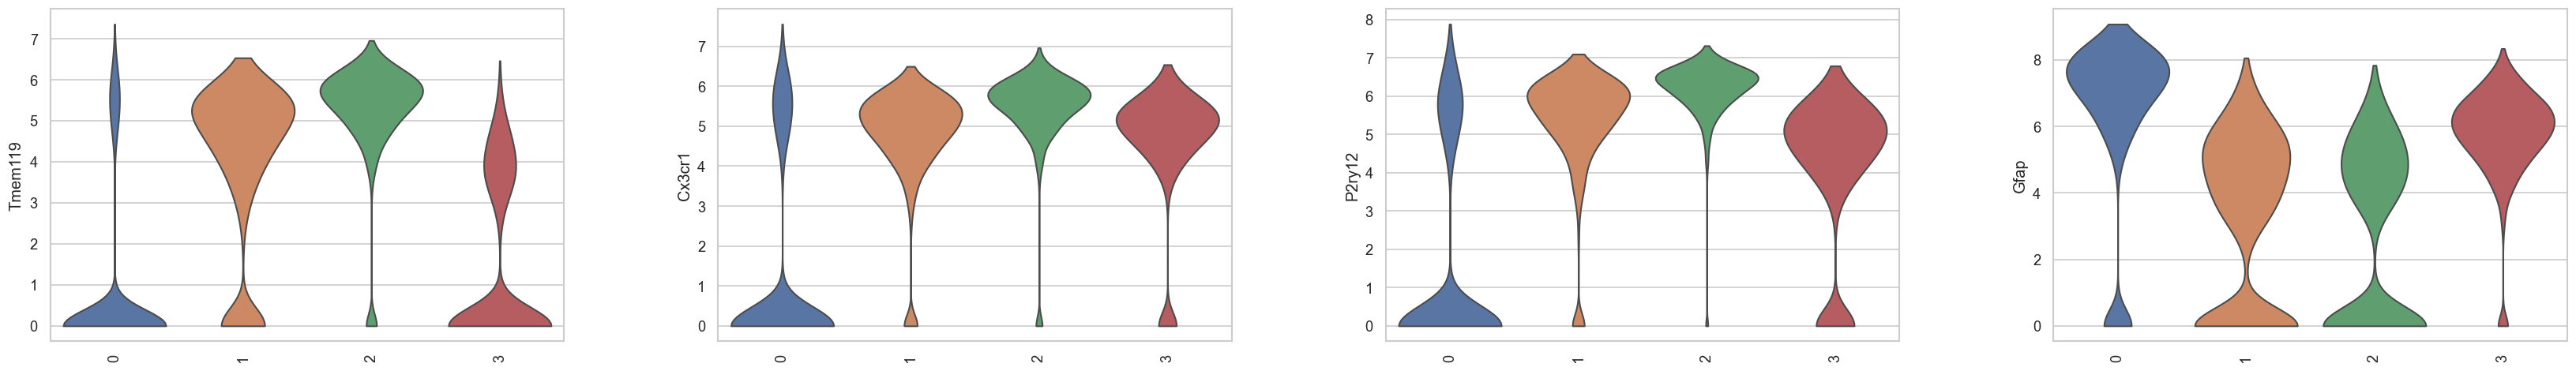

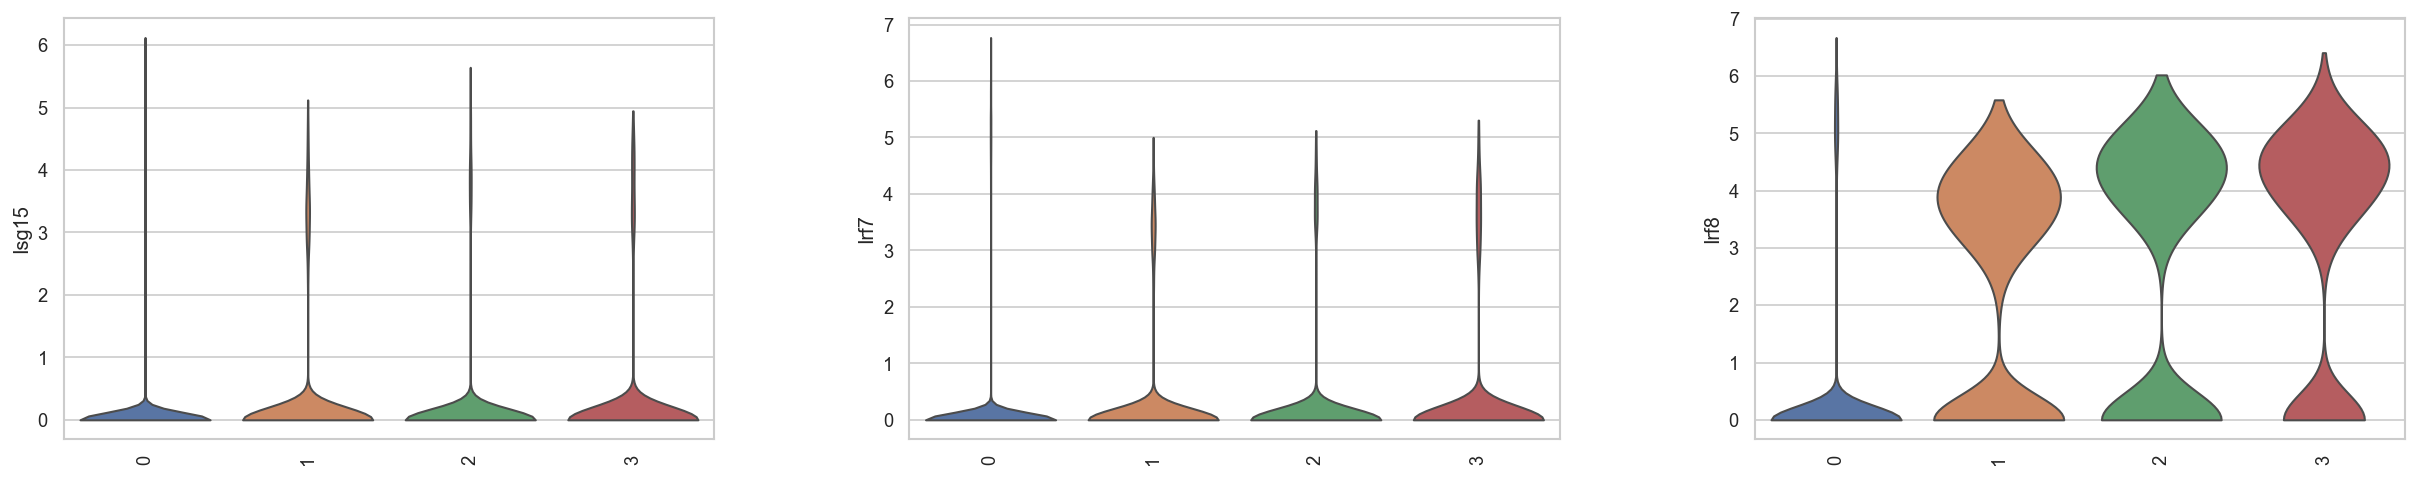

In [ ]:
all_microglia_guide_genes = list(dict.fromkeys(
    lymphocyte_guide_genes["DAM genes"] + lymphocyte_guide_genes["HOM genes"] + ["Gfap"] + ["Isg15", "Irf7", "Irf8"]))

for start in range(0, len(all_microglia_guide_genes), 4):
    genes, page = all_microglia_guide_genes[start: start + 4], start // 4 + 1
    sc.pl.violin(microglia, keys=genes, groupby="microglia_leiden", use_raw=True, multi_panel=True, rotation=90, stripplot=False, show=False)
    plt.savefig(OUTPUT_DIR / f"microglia_guide_genes_violin_page_{page}_20260819.png", dpi=300, bbox_inches="tight")
    plt.show()

### 0 - maybe astrocytes - remove 
### 1 & 2 - Homeostatic
### 3 - DAM 

In [58]:
lymphocyte_guide_genes

{'T-cell genes': ['Cd3e', 'Cd2', 'Cd4', 'Cd8a', 'Foxp3'],
 'B-cell genes': ['Cd19', 'Ms4a1', 'Ighd', 'Ighm'],
 'DAM genes': ['Trem2',
  'Apoe',
  'Axl',
  'Itgax',
  'B2m',
  'Cd9',
  'Fabp5',
  'Spp1',
  'Actb',
  'Vim',
  'Csf1r',
  'Fcgr2b'],
 'HOM genes': ['Tmem119', 'Cx3cr1', 'P2ry12']}

#### Feature plot of guide genes on the subclustered UMAP

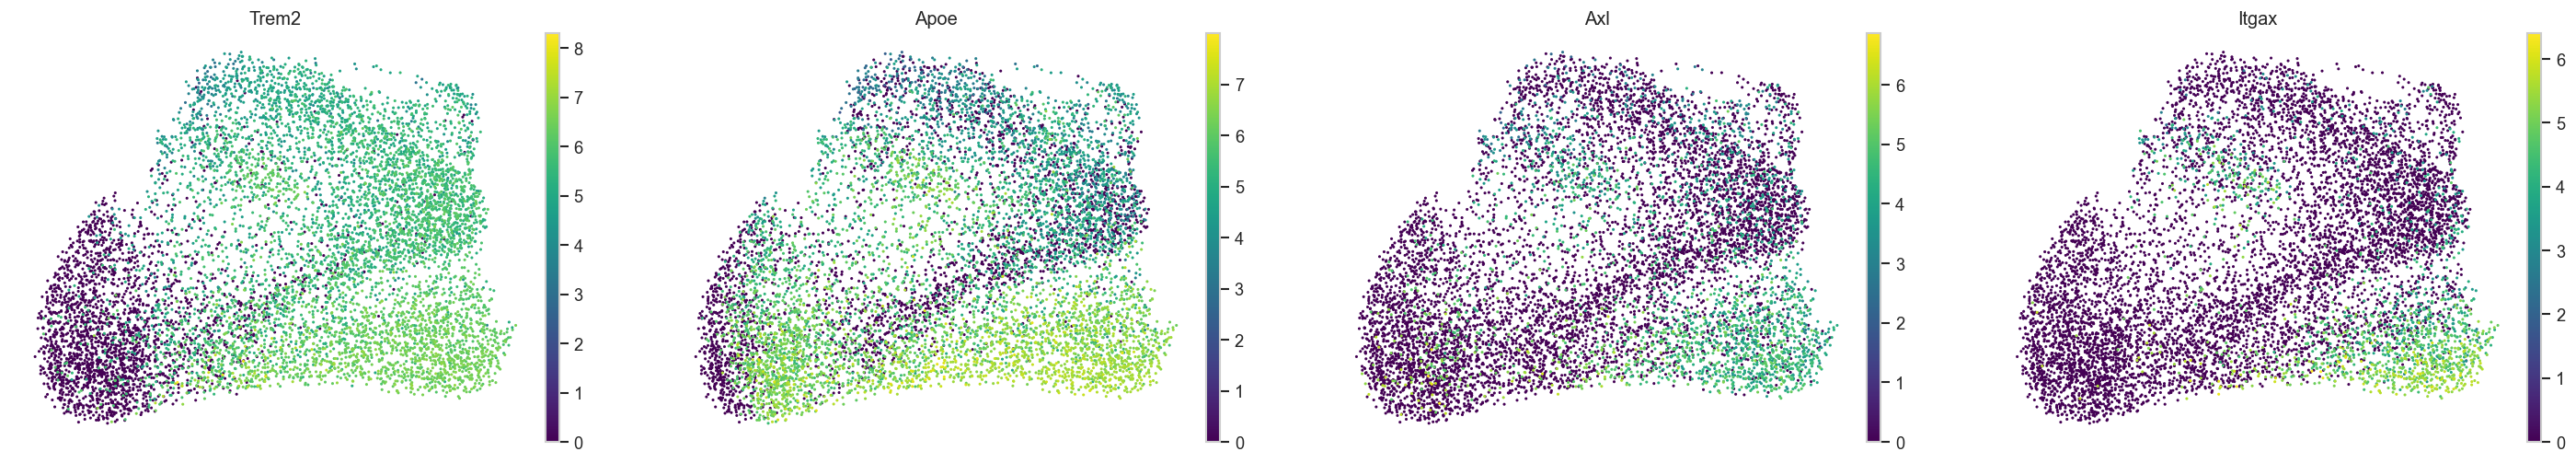

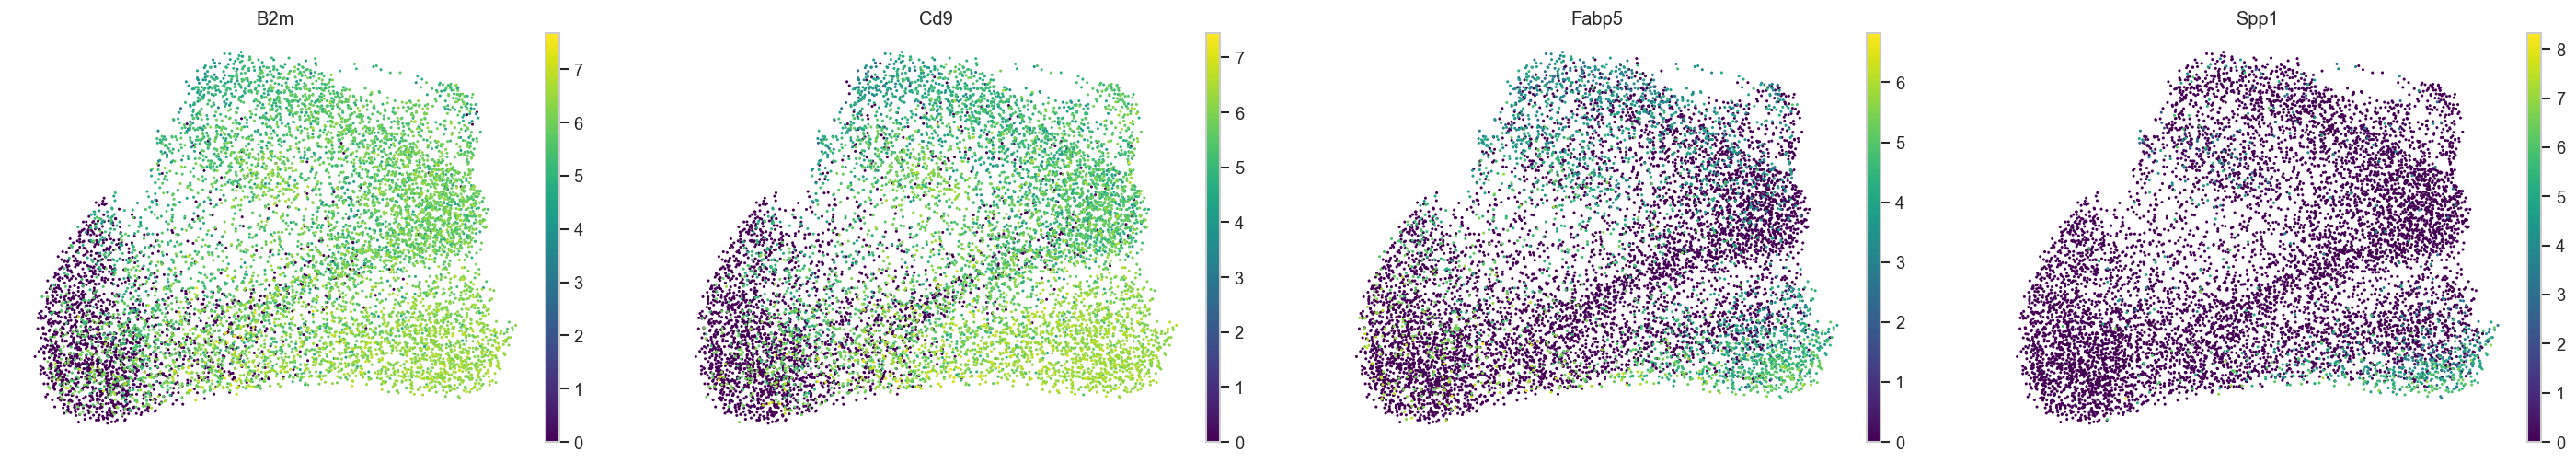

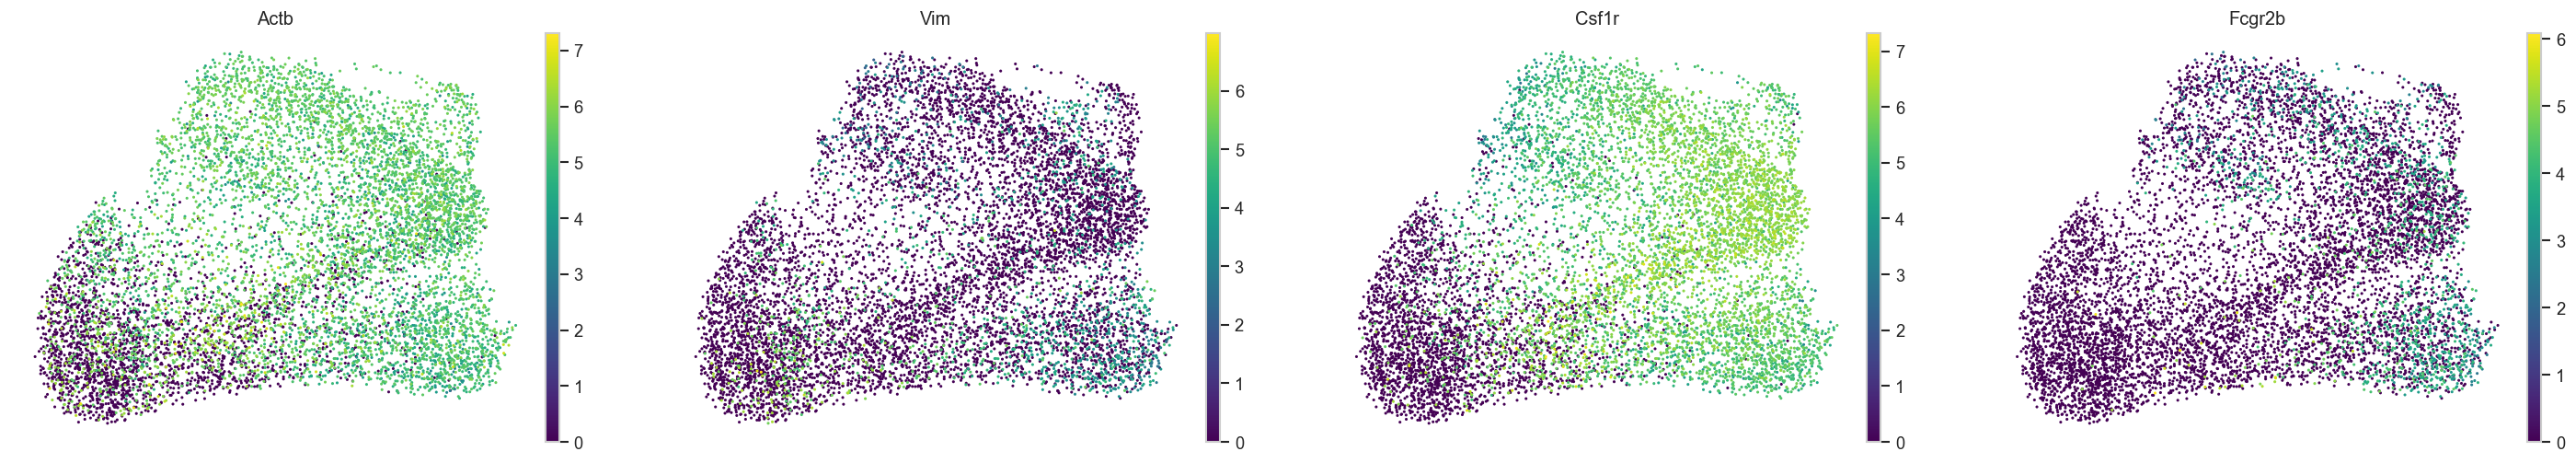

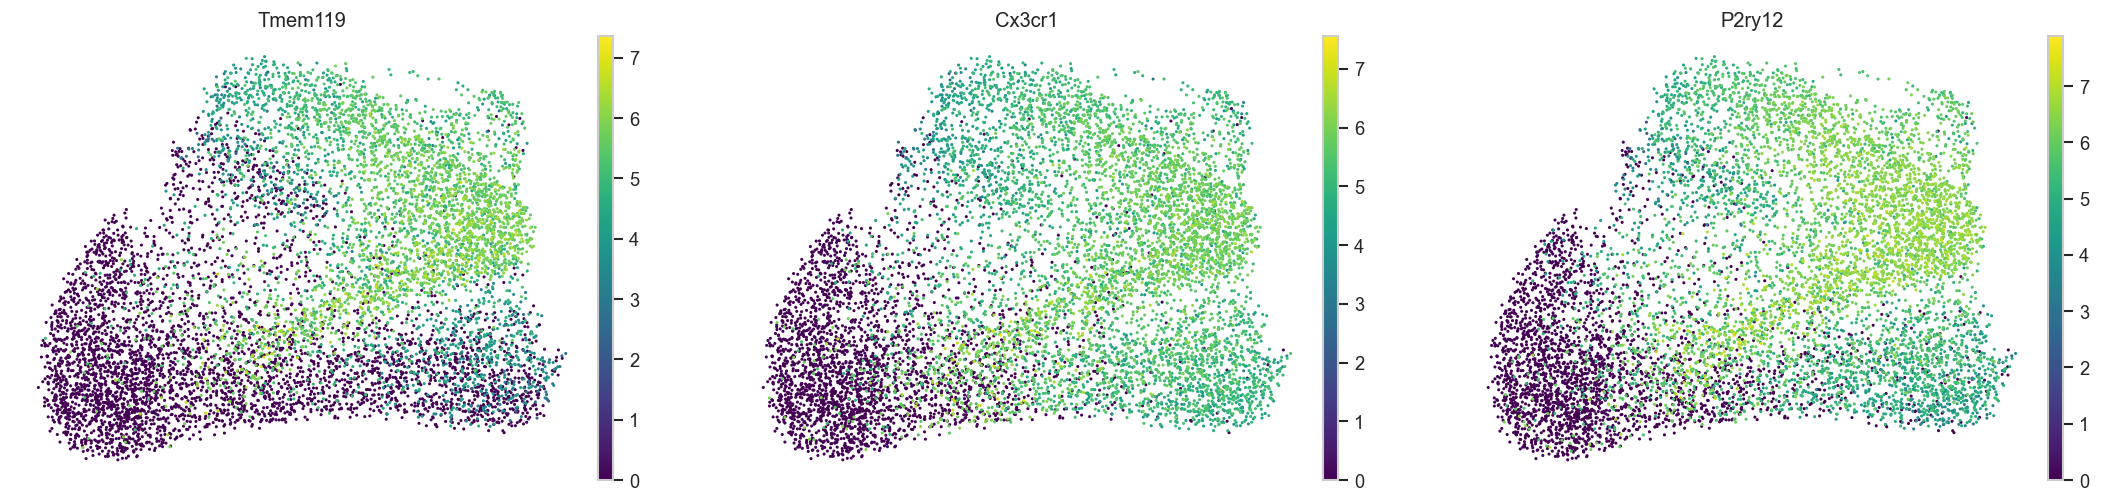

In [59]:
for start in range(0, len(all_microglia_guide_genes), 4):
    genes, page = all_microglia_guide_genes[start:start + 4], start // 4 + 1
    sc.pl.umap(microglia, color=genes, use_raw=True, ncols=4, cmap="viridis", frameon=False, show=False)
    plt.savefig(OUTPUT_DIR / f"microglia_guide_genes_featureplots_page_{page}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [60]:
distance_col, celltype_col = "distance_to_nearest_plaque_center_um", "manual_celltype"
distances = [15, 20, 25, 30, 50]
cells = adata.obs.loc[adata.obs[distance_col].notna(), [distance_col, celltype_col]].copy()
cells[celltype_col] = cells[celltype_col].astype(str)

celltype_order = cells.loc[cells[distance_col] <= max(distances), celltype_col].value_counts().index.tolist()
counts = pd.DataFrame(
    [cells.loc[cells[distance_col] <= d, celltype_col].value_counts().reindex(celltype_order, fill_value=0) for d in distances],
    index=[f"{d} µm" for d in distances],
).astype(int)

percent = counts.div(counts.sum(axis=1), axis=0).mul(100)
display(counts)
display(percent.round(2))

manual_celltype,Cortical excitatory neurons,Microglia,Oligodendrocytes,Endothelial/Vasculature,Parenchymal astrocytes,Hypothalamic inhibitory neurons,Thalamic excitatory neurons,OPCs,Striatal inhibitory neurons,Dentate gyrus excitatory neurons,CD8,CA1/CA3 excitatory neurons,Bcells,unknown (REMOVE),Macrophages,Cholinergic neurons
15 µm,20,224,26,51,14,15,8,8,5,0,11,0,1,0,1,0
20 µm,60,375,66,90,50,29,19,20,8,0,12,0,1,0,1,0
25 µm,137,499,111,119,85,50,35,37,14,1,15,2,1,0,1,0
30 µm,237,585,178,174,133,85,50,53,31,3,18,2,1,0,1,0
50 µm,847,813,548,454,406,263,151,122,103,50,29,17,4,2,1,1


manual_celltype,Cortical excitatory neurons,Microglia,Oligodendrocytes,Endothelial/Vasculature,Parenchymal astrocytes,Hypothalamic inhibitory neurons,Thalamic excitatory neurons,OPCs,Striatal inhibitory neurons,Dentate gyrus excitatory neurons,CD8,CA1/CA3 excitatory neurons,Bcells,unknown (REMOVE),Macrophages,Cholinergic neurons
15 µm,5.21,58.33,6.77,13.28,3.65,3.91,2.08,2.08,1.30,0.00,2.86,0.00,0.26,0.00,0.26,0.00
20 µm,8.21,51.30,9.03,12.31,6.84,3.97,2.60,2.74,1.09,0.00,1.64,0.00,0.14,0.00,0.14,0.00
25 µm,12.38,45.08,10.03,10.75,7.68,4.52,3.16,3.34,1.26,0.09,1.36,0.18,0.09,0.00,0.09,0.00
30 µm,15.28,37.72,11.48,11.22,8.58,5.48,3.22,3.42,2.00,0.19,1.16,0.13,0.06,0.00,0.06,0.00
50 µm,22.23,21.33,14.38,11.91,10.65,6.90,3.96,3.20,2.70,1.31,0.76,0.45,0.10,0.05,0.03,0.03


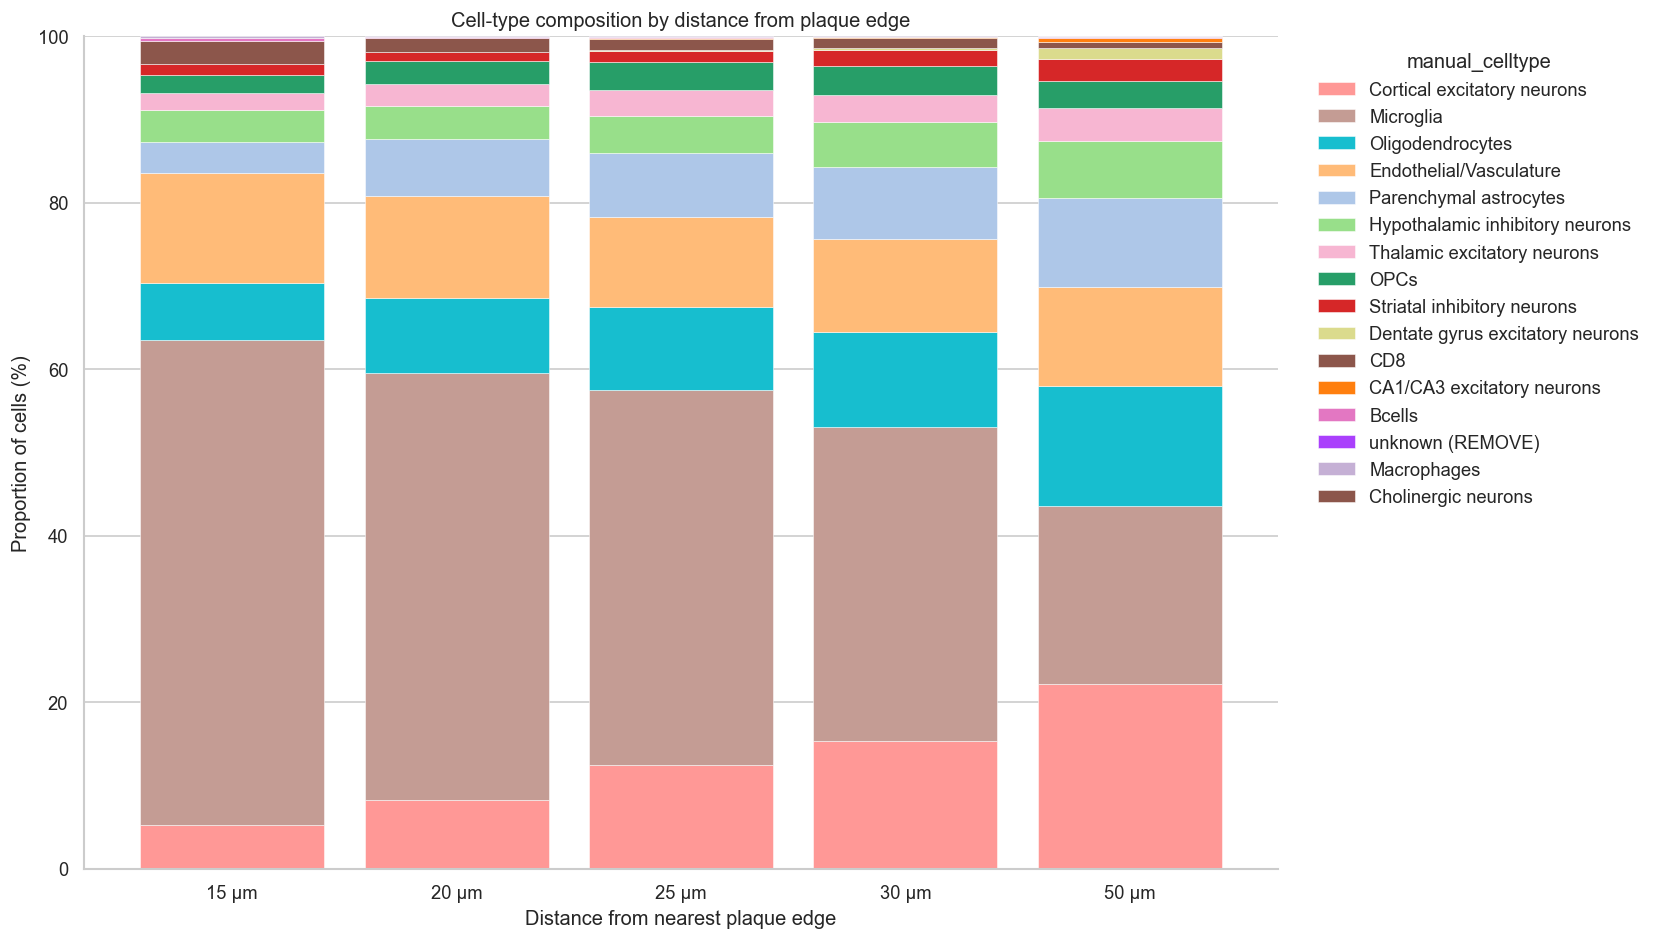

In [61]:
fallback_colors = sns.color_palette("tab20", n_colors=max(1, len(celltype_order))).as_hex()
colors = [palette.get(celltype, fallback_colors[i]) for i, celltype in enumerate(celltype_order)]

fig, ax = plt.subplots(figsize=(14, 8))

percent.plot(
    kind="bar",
    stacked=True,
    color=colors,
    width=0.82,
    edgecolor="white",
    linewidth=0.3,
    ax=ax,
)

ax.set(
    title="Cell-type composition by distance from plaque edge",
    xlabel="Distance from nearest plaque edge",
    ylabel="Proportion of cells (%)",
    ylim=(0, 100),
)

ax.tick_params(axis="x", rotation=0)
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title=ANNOTATION_COLUMN, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "manual_celltype_by_plaque_edge_distance_stacked_barplot.png", dpi=300, bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "manual_celltype_by_plaque_edge_distance_stacked_barplot.pdf", bbox_inches="tight")
plt.show()

,CD8_count
<15 µm,15
<20 µm,19
<25 µm,24
<30 µm,27
<50 µm,34


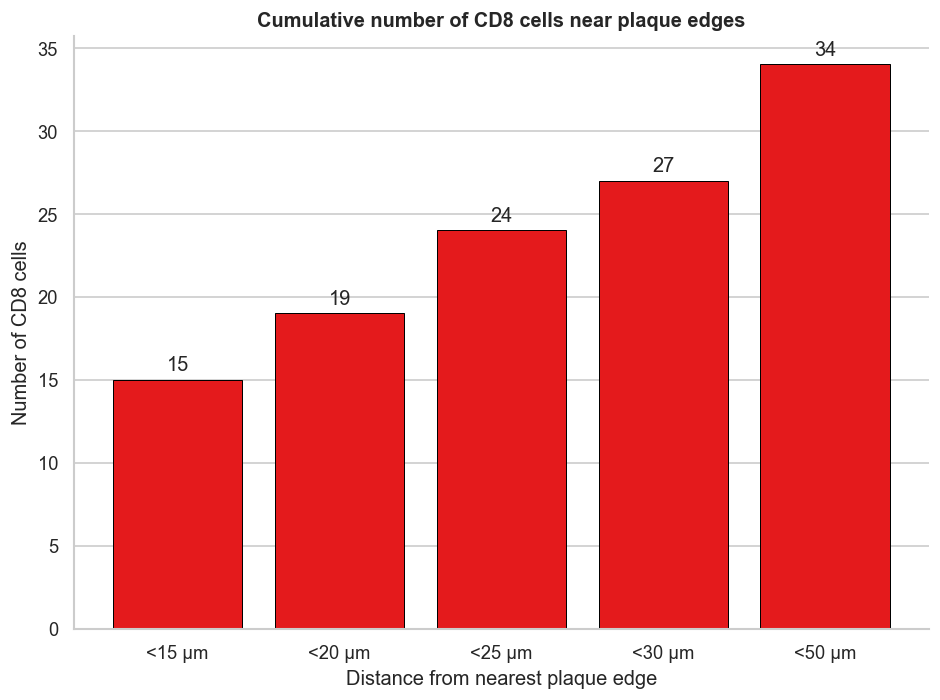

In [62]:
distance_col = "distance_to_nearest_plaque_edge_um"
celltype_col = "manual_celltype"
distances = [15, 20, 25, 30, 50]

valid_edge_cells = (
    adata.obs["plaque_edge_analysis_valid"].fillna(False)
    & adata.obs[distance_col].notna()
)

cd8_cells = adata.obs.loc[
    valid_edge_cells
    & adata.obs[celltype_col].astype(str).eq("CD8")
].copy()

cd8_counts = pd.Series(
    [(cd8_cells[distance_col] < distance).sum() for distance in distances],
    index=[f"<{distance} µm" for distance in distances],
    name="CD8_count",
)

display(cd8_counts.to_frame())
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    cd8_counts.index,
    cd8_counts.values,
    color="#E41A1C",
    edgecolor="black",
    linewidth=0.6,
)

ax.bar_label(bars, labels=[f"{count:,}" for count in cd8_counts], padding=3)
ax.set_title("Cumulative number of CD8 cells near plaque edges", weight="bold")
ax.set_xlabel("Distance from nearest plaque edge")
ax.set_ylabel("Number of CD8 cells")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "CD8_cumulative_counts_by_plaque_edge_distance.png", dpi=300, bbox_inches="tight")
plt.show()



In [64]:
import subprocess

notebook_path = "09_cell_analysis_from_plaques.ipynb"

subprocess.run(
    ["jupyter", "nbconvert", "--to", "html", notebook_path],
    check=True,
)

[NbConvertApp] Converting notebook 09_cell_analysis_from_plaques.ipynb to html
/opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] WARNING | Alternative text is missing on 21 image(s).
[NbConvertApp] Writing 9951268 bytes to 09_cell_analysis_from_plaques.html


CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', '09_cell_analysis_from_plaques.ipynb'], returncode=0)

In [ ]:
#### re-define the cells near the plaque, using the plaque edge and not the center (40, 50 )
#### send a single cell type of object to Irene to work on the seurat app for microglia ()
#### divide the plaques into if they have CD8 T-cells or not (within the 50 um diameter)
#### DEG analysis between - microglia around the Tcell- plaques vs the microglia around the Tcell+
#### Subcluster the T-cells (gzmk, ifn etc)

#### Save the microglia object for the seurat explorer app

In [30]:

EXPORT_PATH = Path(OUTPUT_DIR) / "microglia_singlecell_for_seurat_explorer.h5ad"

# Use raw counts
counts = microglia.layers["counts"].copy() if "counts" in microglia.layers else microglia.X.copy()

# Retain useful metadata
metadata_columns = [
    col for col in [
        "batch", "manual_celltype", "manual_celltype_original",
        "microglia_leiden", "microglia_subtype",
        "x_centroid", "y_centroid", "total_counts", "n_genes_by_counts"
    ]
    if col in microglia.obs.columns
]

obs_export = microglia.obs[metadata_columns].copy()
var_export = microglia.var.copy()

# Convert categorical/string metadata to standard strings for R compatibility
for col in obs_export.columns:
    if isinstance(obs_export[col].dtype, pd.CategoricalDtype) or pd.api.types.is_string_dtype(obs_export[col]):
        obs_export[col] = obs_export[col].astype(str)

for col in var_export.columns:
    if isinstance(var_export[col].dtype, pd.CategoricalDtype) or pd.api.types.is_string_dtype(var_export[col]):
        var_export[col] = var_export[col].astype(str)

# Create a clean microglia-only single-cell object
microglia_export = ad.AnnData(
    X=counts.copy(),
    obs=obs_export,
    var=var_export,
)

# The Shiny app explicitly looks for an assay named "counts"
microglia_export.layers["counts"] = counts.copy()

# Include the subclustered UMAP if available
if "X_umap" in microglia.obsm:
    microglia_export.obsm["X_umap"] = np.asarray(microglia.obsm["X_umap"]).copy()

microglia_export.uns["export_description"] = (
    "Microglia-only raw-count object prepared for the Seurat Clustering Explorer"
)

microglia_export.write_h5ad(EXPORT_PATH, compression="gzip")

print(microglia_export)
print(f"Saved:\n{EXPORT_PATH}")

test = ad.read_h5ad(EXPORT_PATH, backed="r")

print(test)
print("Counts layer:", "counts" in test.layers)
print("UMAP available:", "X_umap" in test.obsm)
print("Metadata:", test.obs.columns.tolist())
print("Raw-count maximum:", test.layers["counts"][:100].max())

test.file.close()

AnnData object with n_obs × n_vars = 8738 × 480
    obs: 'batch', 'manual_celltype', 'manual_celltype_original', 'microglia_leiden', 'x_centroid', 'y_centroid', 'total_counts', 'n_genes_by_counts'
    var: 'gene_ids', 'feature_types'
    uns: 'export_description'
    obsm: 'X_umap'
    layers: 'counts'
Saved:
/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/09_Cell_Analysis_From_Plaques/microglia_singlecell_for_seurat_explorer.h5ad
AnnData object with n_obs × n_vars = 8738 × 480 backed at '/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/09_Cell_Analysis_From_Plaques/microglia_singlecell_for_seurat_explorer.h5ad'
    obs: 'batch', 'manual_celltype', 'manual_celltype_original', 'microglia_lei

### Assign the plaques are T-cells negative or positive

In [65]:
T_CELL_LABELS = ["CD8", "CD4"]
CELLTYPE_COLUMN = "manual_celltype"
WITHIN_50_COLUMN = "within_50um_of_plaque_edge"
PLAQUE_ID_COLUMN = "plaque_edge_within_50um_id"

required_columns = [CELLTYPE_COLUMN, WITHIN_50_COLUMN, PLAQUE_ID_COLUMN]
missing_columns = [column for column in required_columns if column not in adata.obs.columns]
assert not missing_columns, f"Missing columns: {missing_columns}"

In [66]:
celltype_values = adata.obs[CELLTYPE_COLUMN].astype(str)

tcell_within_50 = (
    celltype_values.isin(T_CELL_LABELS)
    & adata.obs[WITHIN_50_COLUMN].fillna(False)
    & adata.obs[PLAQUE_ID_COLUMN].notna()
)

tcell_plaque_ids = adata.obs.loc[tcell_within_50, PLAQUE_ID_COLUMN].astype(int)
tcell_counts_by_plaque = tcell_plaque_ids.value_counts().sort_index()

print("T cells within 50 µm of a plaque edge:", int(tcell_within_50.sum()))
print("Plaques containing nearby T cells:", len(tcell_counts_by_plaque))

T cells within 50 µm of a plaque edge: 35
Plaques containing nearby T cells: 23


In [67]:
PLAQUE_TABLE_PATH = INPUT_H5AD.parent / "final_filtered_plaque_coordinates_and_radii.csv"

if PLAQUE_TABLE_PATH.exists():
    plaque_status = pd.read_csv(PLAQUE_TABLE_PATH)
else:
    n_plaques = int(adata.uns["plaque_edge_proximity"]["n_final_plaques"])
    plaque_status = pd.DataFrame({"plaque_id": np.arange(1, n_plaques + 1)})

plaque_status["plaque_id"] = plaque_status["plaque_id"].astype(int)
plaque_status["n_tcells_within_50um_edge"] = plaque_status["plaque_id"].map(tcell_counts_by_plaque).fillna(0).astype(int)
plaque_status["tcell_status"] = np.where(
    plaque_status["n_tcells_within_50um_edge"] > 0,
    "T-cell positive",
    "T-cell negative",
)

display(plaque_status)
display(plaque_status["tcell_status"].value_counts())

,plaque_id,if_x_px,if_y_px,radius_px,radius_um,diameter_um,n_tcells_within_50um_edge,tcell_status
0,1,3284.0,1886.0,7.606696,9.867986,19.735972,0,T-cell negative
1,2,1312.0,1832.0,6.010754,7.797607,15.595215,0,T-cell negative
2,3,881.0,3487.0,9.626385,12.488080,24.976160,0,T-cell negative
3,4,802.0,2454.0,12.182331,15.803848,31.607696,0,T-cell negative
4,5,2194.0,1426.0,9.626385,12.488080,24.976160,0,T-cell negative
...,...,...,...,...,...,...,...,...
160,161,829.0,1726.0,6.010754,7.797607,15.595215,0,T-cell negative
161,162,3026.0,3378.0,6.010754,7.797607,15.595215,0,T-cell negative
162,163,3028.0,3377.0,6.010754,7.797607,15.595215,0,T-cell negative
163,164,1412.0,2962.0,6.010754,7.797607,15.595215,0,T-cell negative


tcell_status
T-cell negative    142
T-cell positive     23
Name: count, dtype: int64

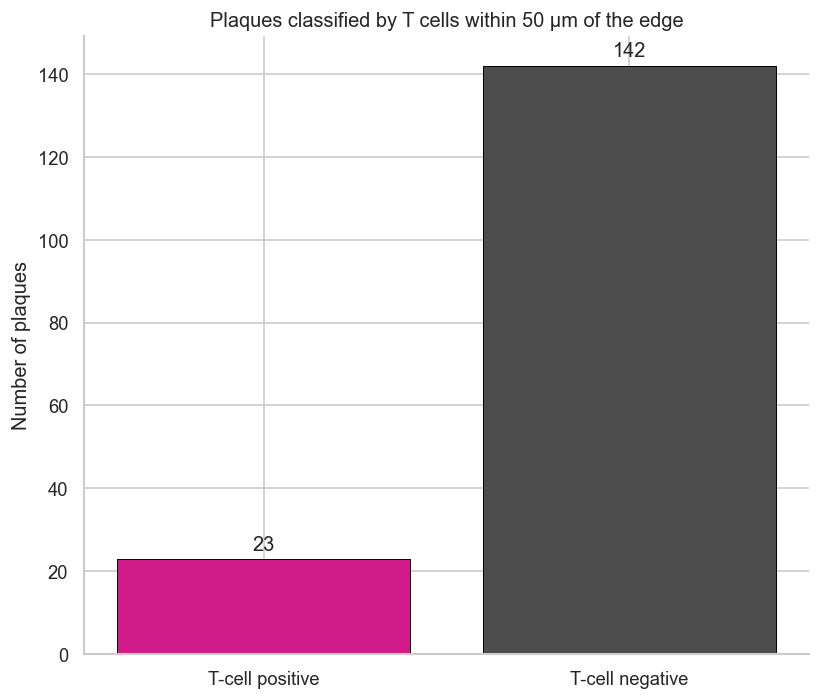

In [69]:
status_map = plaque_status.set_index("plaque_id")["tcell_status"]
count_map = plaque_status.set_index("plaque_id")["n_tcells_within_50um_edge"]

nearest_ids = adata.obs["nearest_plaque_edge_id"]

adata.obs["nearest_plaque_tcell_status"] = nearest_ids.map(status_map).astype("category")
adata.obs["nearest_plaque_tcell_count_50um"] = nearest_ids.map(count_map).astype("Int64")

pd.crosstab(
    adata.obs["nearest_plaque_tcell_status"],
    adata.obs["batch"],
    margins=True,
)

status_counts = plaque_status["tcell_status"].value_counts().reindex(
    ["T-cell positive", "T-cell negative"],
    fill_value=0,
)

fig, ax = plt.subplots(figsize=(7, 6))

bars = ax.bar(
    status_counts.index,
    status_counts.values,
    color=["#d01c8b", "#4d4d4d"],
    edgecolor="black",
    linewidth=0.6,
)

ax.bar_label(bars, labels=[f"{value:,}" for value in status_counts], padding=3)
ax.set_title("Plaques classified by T cells within 50 µm of the edge")
ax.set_xlabel("")
ax.set_ylabel("Number of plaques")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Tcell_positive_negative_plaques_50um_edge.png", dpi=300, bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "Tcell_positive_negative_plaques_50um_edge.pdf", bbox_inches="tight")
plt.show()

In [70]:
PLAQUE_STATUS_CSV = OUTPUT_DIR / "plaque_Tcell_status_within_50um_edge.csv"
TCELL_ANNOTATED_H5AD = OUTPUT_DIR / "adata_with_Tcell_positive_negative_plaque_labels.h5ad"

plaque_status.to_csv(PLAQUE_STATUS_CSV, index=False)
adata.uns["plaque_Tcell_classification"] = {
    "celltype_column": CELLTYPE_COLUMN,
    "T_cell_labels": T_CELL_LABELS,
    "distance_definition": "<50 µm from detected plaque edge",
    "positive_definition": "at least one T cell within 50 µm of plaque edge",
    "n_positive_plaques": int((plaque_status["tcell_status"] == "T-cell positive").sum()),
    "n_negative_plaques": int((plaque_status["tcell_status"] == "T-cell negative").sum()),
}

adata.write_h5ad(TCELL_ANNOTATED_H5AD, compression="gzip")

print("Saved plaque table:", PLAQUE_STATUS_CSV)
print("Saved annotated H5AD:", TCELL_ANNOTATED_H5AD)

Saved plaque table: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/09_Cell_Analysis_From_Plaques/plaque_Tcell_status_within_50um_edge.csv
Saved annotated H5AD: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/09_Cell_Analysis_From_Plaques/adata_with_Tcell_positive_negative_plaque_labels.h5ad


### Select plaque-associated microglia

In [71]:
MICROGLIA_DISTANCE_UM = 50
CELLTYPE_COLUMN = "manual_celltype"
DISTANCE_COLUMN = "distance_to_nearest_plaque_edge_um"
PLAQUE_ID_COLUMN = "nearest_plaque_edge_id"
PLAQUE_STATUS_COLUMN = "nearest_plaque_tcell_status"
DEG_GROUP_COLUMN = "plaque_Tcell_group"

required_columns = [
    CELLTYPE_COLUMN,
    DISTANCE_COLUMN,
    PLAQUE_ID_COLUMN,
    PLAQUE_STATUS_COLUMN,
    "plaque_edge_analysis_valid",
]

missing_columns = [column for column in required_columns if column not in adata.obs.columns]
assert not missing_columns, f"Missing columns: {missing_columns}"

In [72]:
microglia_mask = (
    adata.obs["plaque_edge_analysis_valid"].fillna(False)
    & adata.obs[CELLTYPE_COLUMN].astype(str).eq("Microglia")
    & adata.obs[DISTANCE_COLUMN].notna()
    & (adata.obs[DISTANCE_COLUMN] < MICROGLIA_DISTANCE_UM)
    & adata.obs[PLAQUE_STATUS_COLUMN].notna()
)

adata_microglia = adata[microglia_mask].copy()
adata_microglia.obs[DEG_GROUP_COLUMN] = adata_microglia.obs[PLAQUE_STATUS_COLUMN].astype(str)
adata_microglia.obs[DEG_GROUP_COLUMN] = pd.Categorical(
    adata_microglia.obs[DEG_GROUP_COLUMN],
    categories=["T-cell positive", "T-cell negative"],
)

print("Plaque-associated microglia:", adata_microglia.n_obs)
display(adata_microglia.obs[DEG_GROUP_COLUMN].value_counts())

Plaque-associated microglia: 928


plaque_Tcell_group
T-cell negative    733
T-cell positive    195
Name: count, dtype: int64

In [73]:
microglia_plaque_summary = (
    adata_microglia.obs
    .groupby(DEG_GROUP_COLUMN, observed=True)
    .agg(
        n_microglia=(DEG_GROUP_COLUMN, "size"),
        n_plaques=(PLAQUE_ID_COLUMN, "nunique"),
        median_edge_distance_um=(DISTANCE_COLUMN, "median"),
    )
)

display(microglia_plaque_summary)

,n_microglia,n_plaques,median_edge_distance_um
plaque_Tcell_group,,,
T-cell positive,195,22,12.750577
T-cell negative,733,118,12.051105


In [74]:
microglia_per_plaque = (
    adata_microglia.obs
    .groupby([DEG_GROUP_COLUMN, PLAQUE_ID_COLUMN], observed=True)
    .size()
    .rename("n_microglia")
    .reset_index()
)

display(microglia_per_plaque)

,plaque_Tcell_group,nearest_plaque_edge_id,n_microglia
0,T-cell positive,26,9
1,T-cell positive,35,9
2,T-cell positive,36,5
3,T-cell positive,42,10
4,T-cell positive,56,27
...,...,...,...
135,T-cell negative,160,4
136,T-cell negative,161,1
137,T-cell negative,162,1
138,T-cell negative,164,3


In [76]:
assert "counts" in adata_microglia.layers, "The original counts layer is missing."

adata_microglia.X = adata_microglia.layers["counts"].copy()
sc.pp.filter_genes(adata_microglia, min_cells=10)
sc.pp.normalize_total(adata_microglia, target_sum=1e4)
sc.pp.log1p(adata_microglia)

print("Microglia used for DEG:", adata_microglia.n_obs)
print("Genes used for DEG:", adata_microglia.n_vars)

group_counts = adata_microglia.obs[DEG_GROUP_COLUMN].value_counts()
assert group_counts.get("T-cell positive", 0) >= 3, "Too few microglia near T-cell-positive plaques."
assert group_counts.get("T-cell negative", 0) >= 3, "Too few microglia near T-cell-negative plaques."

display(group_counts)

Microglia used for DEG: 928
Genes used for DEG: 350


plaque_Tcell_group
T-cell negative    733
T-cell positive    195
Name: count, dtype: int64

In [77]:
sc.tl.rank_genes_groups(
    adata_microglia,
    groupby=DEG_GROUP_COLUMN,
    groups=["T-cell positive"],
    reference="T-cell negative",
    method="wilcoxon",
    pts=True,
    use_raw=False,
    key_added="microglia_Tcell_positive_vs_negative",
)

deg_microglia = sc.get.rank_genes_groups_df(
    adata_microglia,
    group="T-cell positive",
    key="microglia_Tcell_positive_vs_negative",
)

deg_microglia["comparison"] = "Microglia near T-cell-positive vs T-cell-negative plaques"
deg_microglia["distance_from_plaque_edge_um"] = f"<{MICROGLIA_DISTANCE_UM}"
deg_microglia["n_cells_Tcell_positive"] = int(group_counts["T-cell positive"])
deg_microglia["n_cells_Tcell_negative"] = int(group_counts["T-cell negative"])

display(deg_microglia.head(20))

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,comparison,distance_from_plaque_edge_um,n_cells_Tcell_positive,n_cells_Tcell_negative
0,Gfap,3.129122,0.634795,0.001753,0.187458,0.969231,Microglia near T-cell-positive vs T-cell-negat...,<50,195,733
1,Spp1,2.797391,1.319069,0.005152,0.257586,0.312821,Microglia near T-cell-positive vs T-cell-negat...,<50,195,733
2,Cd9,2.696684,0.378361,0.007003,0.272753,0.861538,Microglia near T-cell-positive vs T-cell-negat...,<50,195,733
3,Apoe,2.425979,0.476040,0.015267,0.445292,0.892308,Microglia near T-cell-positive vs T-cell-negat...,<50,195,733
4,Slc1a3,2.345413,0.690981,0.019006,0.511700,0.543590,Microglia near T-cell-positive vs T-cell-negat...,<50,195,733
5,Ptprc,2.017891,0.953336,0.043603,0.726710,0.251282,Microglia near T-cell-positive vs T-cell-negat...,<50,195,733
6,B2m,1.624534,0.150827,0.104262,0.996402,0.897436,Microglia near T-cell-positive vs T-cell-negat...,<50,195,733
7,Mpeg1,1.539309,0.415303,0.123729,0.996402,0.825641,Microglia near T-cell-positive vs T-cell-negat...,<50,195,733
8,Sox9,1.509849,0.658794,0.131082,0.996402,0.292308,Microglia near T-cell-positive vs T-cell-negat...,<50,195,733
9,C1qa,1.382688,0.313651,0.166761,0.996402,0.851282,Microglia near T-cell-positive vs T-cell-negat...,<50,195,733


In [78]:
FDR_THRESHOLD = 0.05
LOGFC_THRESHOLD = 0.25

deg_microglia["significant"] = (
    (deg_microglia["pvals_adj"] < FDR_THRESHOLD)
    & (deg_microglia["logfoldchanges"].abs() >= LOGFC_THRESHOLD)
)

deg_microglia["direction"] = "Not significant"
deg_microglia.loc[
    deg_microglia["significant"] & (deg_microglia["logfoldchanges"] > 0),
    "direction",
] = "Higher near T-cell-positive plaques"

deg_microglia.loc[
    deg_microglia["significant"] & (deg_microglia["logfoldchanges"] < 0),
    "direction",
] = "Higher near T-cell-negative plaques"

display(deg_microglia["direction"].value_counts())

direction
Not significant    350
Name: count, dtype: int64

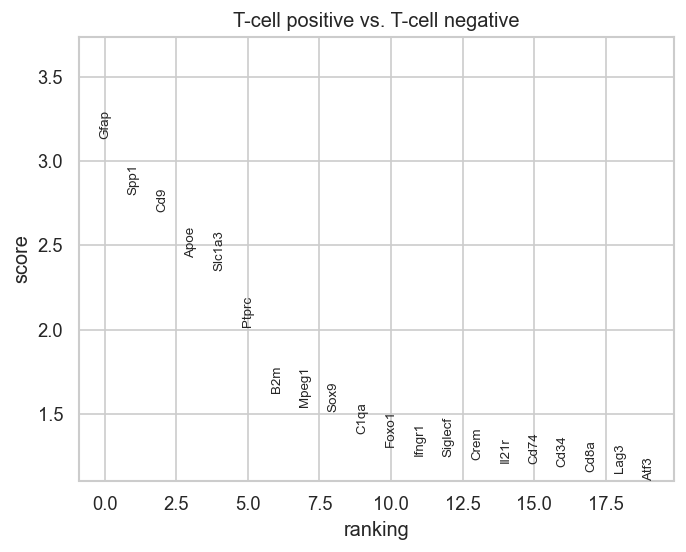

In [79]:
sc.pl.rank_genes_groups(
    adata_microglia,
    key="microglia_Tcell_positive_vs_negative",
    groups=["T-cell positive"],
    n_genes=20,
    sharey=False,
)

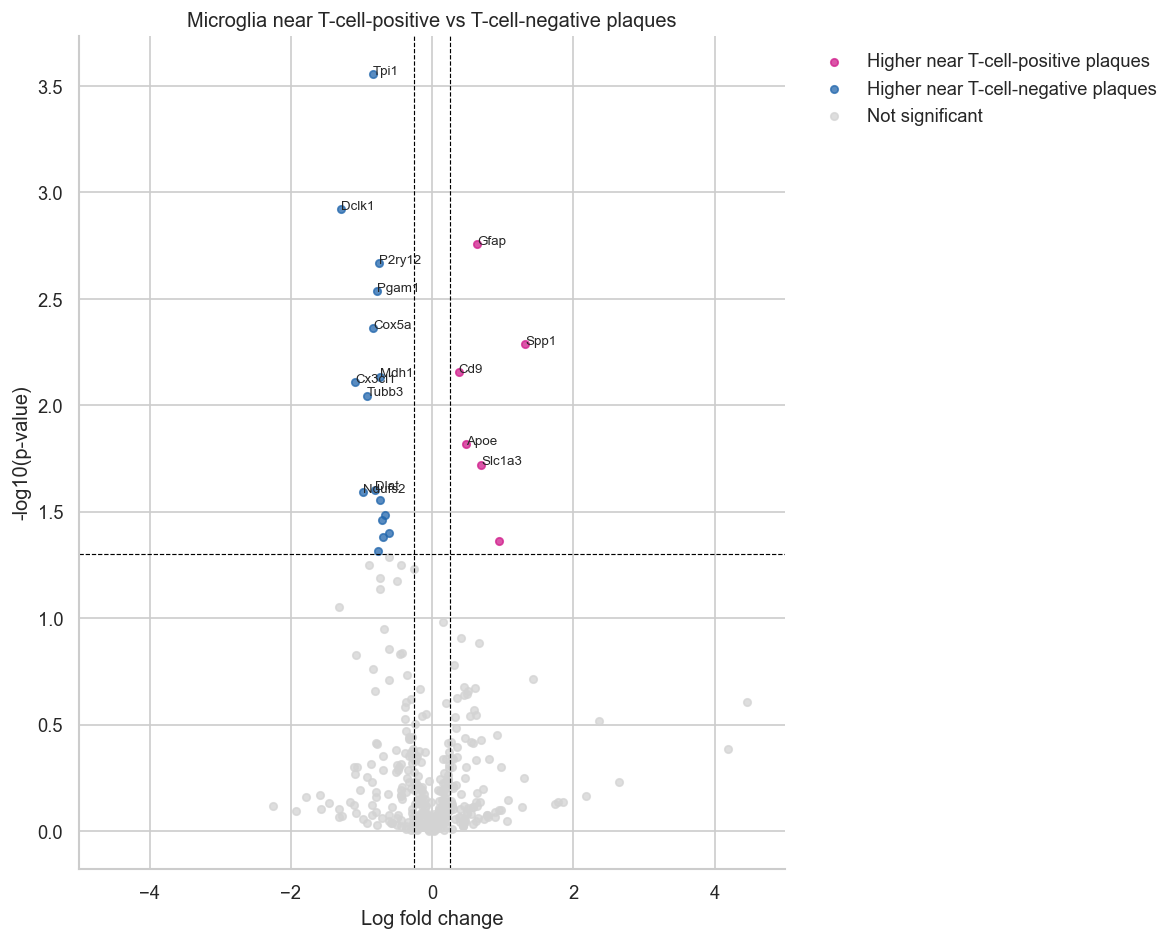

In [84]:
P_VALUE_THRESHOLD = 0.05
LOGFC_THRESHOLD = 0.25

volcano = deg_microglia.copy()
volcano["minus_log10_pvalue"] = -np.log10(volcano["pvals"].clip(lower=1e-300))

volcano["volcano_direction"] = "Not significant"
volcano.loc[
    (volcano["pvals"] < P_VALUE_THRESHOLD)
    & (volcano["logfoldchanges"] >= LOGFC_THRESHOLD),
    "volcano_direction",
] = "Higher near T-cell-positive plaques"

volcano.loc[
    (volcano["pvals"] < P_VALUE_THRESHOLD)
    & (volcano["logfoldchanges"] <= -LOGFC_THRESHOLD),
    "volcano_direction",
] = "Higher near T-cell-negative plaques"

volcano_colors = {
    "Higher near T-cell-positive plaques": "#d01c8b",
    "Higher near T-cell-negative plaques": "#2166ac",
    "Not significant": "lightgray",
}

fig, ax = plt.subplots(figsize=(10, 8))

for direction, color in volcano_colors.items():
    selected = volcano["volcano_direction"].eq(direction)

    ax.scatter(
        volcano.loc[selected, "logfoldchanges"],
        volcano.loc[selected, "minus_log10_pvalue"],
        s=20,
        c=color,
        alpha=0.75,
        label=direction,
    )

ax.axvline(LOGFC_THRESHOLD, color="black", linestyle="--", linewidth=0.7)
ax.axvline(-LOGFC_THRESHOLD, color="black", linestyle="--", linewidth=0.7)
ax.axhline(-np.log10(P_VALUE_THRESHOLD), color="black", linestyle="--", linewidth=0.7)

genes_to_label = (
    volcano.loc[volcano["volcano_direction"] != "Not significant"]
    .sort_values("pvals")
    .head(15)
)

for _, gene in genes_to_label.iterrows():
    ax.text(
        gene["logfoldchanges"],
        gene["minus_log10_pvalue"],
        gene["names"],
        fontsize=8,
    )

ax.set_title("Microglia near T-cell-positive vs T-cell-negative plaques")
ax.set_xlabel("Log fold change")
ax.set_ylabel("-log10(p-value)")
ax.set_xlim(-5, 5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "microglia_Tcell_positive_vs_negative_volcano_pvalue.png", dpi=300, bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "microglia_Tcell_positive_vs_negative_volcano_pvalue.pdf", bbox_inches="tight")
plt.show()

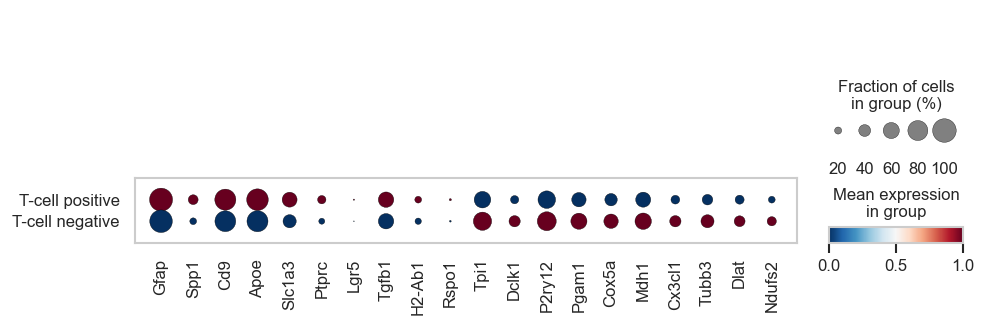

In [ ]:
top_positive = (
    deg_microglia.loc[deg_microglia["logfoldchanges"] > 0]
    .sort_values("pvals_adj")
    .head(10)["names"]
    .tolist()
)

top_negative = (
    deg_microglia.loc[deg_microglia["logfoldchanges"] < 0]
    .sort_values("pvals_adj")
    .head(10)["names"]
    .tolist()
)

top_genes = list(dict.fromkeys(top_positive + top_negative))

if top_genes:
    sc.pl.dotplot(
        adata_microglia,
        var_names=top_genes,
        groupby=DEG_GROUP_COLUMN,
        categories_order=["T-cell positive", "T-cell negative"],
        dendrogram=False,
        standard_scale="var",
        cmap="RdBu_r",
        show=False,
    )

    plt.savefig(OUTPUT_DIR / "microglia_Tcell_positive_vs_negative_dotplot.png", dpi=300, bbox_inches="tight")
    plt.savefig(OUTPUT_DIR / "microglia_Tcell_positive_vs_negative_dotplot.pdf", bbox_inches="tight")
    plt.show()

In [82]:
DEG_CSV = OUTPUT_DIR / "microglia_Tcell_positive_vs_negative_DEG.csv"
DEG_EXCEL = OUTPUT_DIR / "microglia_Tcell_positive_vs_negative_DEG.xlsx"
MICROGLIA_H5AD = OUTPUT_DIR / "microglia_near_Tcell_positive_negative_plaques.h5ad"

deg_microglia.to_csv(DEG_CSV, index=False)

with pd.ExcelWriter(DEG_EXCEL) as writer:
    deg_microglia.to_excel(writer, sheet_name="DEG_all", index=False)
    deg_microglia.loc[deg_microglia["significant"]].to_excel(writer, sheet_name="DEG_significant", index=False)
    microglia_plaque_summary.to_excel(writer, sheet_name="group_summary")
    microglia_per_plaque.to_excel(writer, sheet_name="microglia_per_plaque", index=False)

adata_microglia.write_h5ad(MICROGLIA_H5AD, compression="gzip")

print("Saved DEG CSV:", DEG_CSV)
print("Saved DEG Excel:", DEG_EXCEL)
print("Saved microglia H5AD:", MICROGLIA_H5AD)

Saved DEG CSV: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/09_Cell_Analysis_From_Plaques/microglia_Tcell_positive_vs_negative_DEG.csv
Saved DEG Excel: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/09_Cell_Analysis_From_Plaques/microglia_Tcell_positive_vs_negative_DEG.xlsx
Saved microglia H5AD: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/09_Cell_Analysis_From_Plaques/microglia_near_Tcell_positive_negative_plaques.h5ad
